# 🎓 BCS407 – Artificial Intelligence | Part 2
## AI-Based Smart Campus Safety Detection System — Advanced Iteration
### Model Improvement & Research

| | |
|---|---|
| **Course** | BCS407 Artificial Intelligence — Canadian University Dubai |
| **Model (Baseline)** | YOLOv8s |
| **Experiments** | YOLOv8m upgrade · Hyperparameter optimisation · Expanded Exit dataset |
| **Classes** | Exit · Fire Alarm · Wet Floor Sign · Industrial Safety Helmet |
| **Dataset** | 2,069 images (baseline) |

**Group Members:**
- Suhail Sameer — 20230004090
- Sara Salmanpour — 20220002664
- Mohammad Abdullah — 20230003944
- Marwan Mire — 20240004471
- Fatemeh Najafi — 20230003920

---
> ⚠️ **Before running:** `Runtime > Change runtime type > Hardware accelerator = GPU (T4)`

---
## ⚙️ Step 0 — Environment Setup

### Step 0a — Verify GPU

In [1]:
import torch, subprocess, sys

print('='*55)
print('ENVIRONMENT SPECS (for reproducibility)')
print('='*55)
print(f'Python     : {sys.version}')
print(f'PyTorch    : {torch.__version__}')
print(f'CUDA avail : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    try:
        subprocess.run(['nvidia-smi'])
    except Exception as e:
        print('nvidia-smi not available:', e)
else:
    print('CUDA not available — using CPU (training will be slow)')

ENVIRONMENT SPECS (for reproducibility)
Python     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch    : 2.10.0+cu128
CUDA avail : True
GPU        : Tesla T4
VRAM       : 15.6 GB


### Step 0b — Install Dependencies

In [2]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', 'roboflow', '--quiet'])
import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


### Step 0c — Mount Google Drive & Create Save Directories

In [3]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

# Base save path on Drive — all experiment results go here
DRIVE_BASE = '/content/drive/MyDrive/BCS407_Part2'

dirs_to_create = [
    DRIVE_BASE,
    f'{DRIVE_BASE}/baseline',
    f'{DRIVE_BASE}/exp1_yolov8m',
    f'{DRIVE_BASE}/exp2_hyperparam',
    f'{DRIVE_BASE}/exp3_expanded_data',
    f'{DRIVE_BASE}/final_combined',
]

for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)

print('Drive mounted and directories created:')
for d in dirs_to_create:
    print(f'  {d}')

Mounted at /content/drive
Drive mounted and directories created:
  /content/drive/MyDrive/BCS407_Part2
  /content/drive/MyDrive/BCS407_Part2/baseline
  /content/drive/MyDrive/BCS407_Part2/exp1_yolov8m
  /content/drive/MyDrive/BCS407_Part2/exp2_hyperparam
  /content/drive/MyDrive/BCS407_Part2/exp3_expanded_data
  /content/drive/MyDrive/BCS407_Part2/final_combined


### Step 0d — Set Global Variables & Random Seed
> All experiments use `SEED = 42` for reproducibility

In [4]:
import os, random
import numpy as np
import torch

# ── Reproducibility ──────────────────────────────────────
SEED   = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

# ── Paths ────────────────────────────────────────────────
RUNS_DIR  = '/content/runs/detect'
BASELINE_WEIGHTS = '/content/drive/MyDrive/BCS407_best.pt'  # Part 1 trained model

# ── Shared eval settings (keep identical across all experiments) ──
EVAL_IOU  = 0.5
EVAL_CONF = 0.25

print(f'Seed   : {SEED}')
print(f'Device : {DEVICE}')
print(f'Runs   : {RUNS_DIR}')

Seed   : 42
Device : 0
Runs   : /content/runs/detect


---
## 📥 Step 1 — Download Dataset from Roboflow
> Replace `YOUR_API_KEY_HERE` with your Roboflow API key (do NOT commit the real key to GitHub)

In [5]:
from roboflow import Roboflow

# ── Roboflow credentials — replace API key before running ──
API_KEY      = 'mKzdzWqS3SWg2lGMouYO'
WORKSPACE    = 'mohammads-workspace-ervg9'
PROJECT_NAME = 'bcs_407-project-aui6o'
VERSION      = 1

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
dataset = project.version(VERSION).download('yolov8')

DATASET_PATH = dataset.location
print(f'\nDataset downloaded to: {DATASET_PATH}')
print(f'data.yaml path       : {os.path.join(DATASET_PATH, "data.yaml")}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BCS_407-Project-1 in yolov8:: 100%|██████████| 4142/4142 [00:00<00:00, 8091.82it/s]



Dataset downloaded to: /content/BCS_407-Project-1
data.yaml path       : /content/BCS_407-Project-1/data.yaml


### Step 1b — Verify Dataset Split Counts

In [6]:
import yaml
from pathlib import Path

with open(os.path.join(DATASET_PATH, 'data.yaml'), 'r') as f:
    data_config = yaml.safe_load(f)

print('='*50)
print('DATASET CONFIGURATION')
print('='*50)
print(f'Number of classes : {data_config["nc"]}')
print(f'Class names       : {data_config["names"]}')
print()
for split in ['train', 'valid', 'test']:
    split_path = Path(DATASET_PATH) / split / 'images'
    if split_path.exists():
        count = len(list(split_path.glob('*')))
        print(f'{split:<6} images: {count}')
print('='*50)

DATASET CONFIGURATION
Number of classes : 4
Class names       : ['Exit', 'Fire alarm', 'Wet Floor Sign', 'industrial-safety-helmet']

train  images: 1655
valid  images: 207
test   images: 207


---
## 📊 Section 1 — Baseline Model Analysis

The baseline is the YOLOv8s model trained in Project 1.

**Baseline (Project 1 — Validation Set):**
| Metric | Score |
|---|---|
| mAP@0.50 | 96.79% |
| mAP@0.50:0.95 | 72.38% |
| Precision | 96.17% |
| Recall | 94.25% |

Per the professor feedback, Part 2 uses the **test set** as the official evaluation split.

### Section 1a — Load Baseline Model & Run Test Set Evaluation

In [7]:
from ultralytics import YOLO

# Load Part 1 trained model from Drive
baseline_model = YOLO(BASELINE_WEIGHTS)
print(f'Baseline model loaded from: {BASELINE_WEIGHTS}')

# Evaluate on test set
baseline_metrics = baseline_model.val(
    data   = os.path.join(DATASET_PATH, 'data.yaml'),
    split  = 'test',
    iou    = EVAL_IOU,
    conf   = EVAL_CONF,
    device = DEVICE,
    plots  = True,
    name   = 'baseline_test',
    project= RUNS_DIR,
)

# Print results
print('\n' + '='*57)
print('BASELINE RESULTS (YOLOv8s — Test Set)')
print('='*57)
print(f'Overall mAP@0.50      : {baseline_metrics.box.map50:.4f}')
print(f'Overall mAP@0.50:0.95 : {baseline_metrics.box.map:.4f}')
print(f'Overall Precision     : {baseline_metrics.box.mp:.4f}')
print(f'Overall Recall        : {baseline_metrics.box.mr:.4f}')
print()
print(f'{"Class":<30} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10}')
print('-'*62)
class_names = data_config['names']
for i, name in enumerate(class_names):
    p  = baseline_metrics.box.p[i]     if i < len(baseline_metrics.box.p)     else 0
    r  = baseline_metrics.box.r[i]     if i < len(baseline_metrics.box.r)     else 0
    ap = baseline_metrics.box.ap50[i]  if i < len(baseline_metrics.box.ap50)  else 0
    print(f'{name:<30} {p:>10.4f} {r:>10.4f} {ap:>10.4f}')
print('='*62)

Baseline model loaded from: /content/drive/MyDrive/BCS407_best.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1633.0±660.7 MB/s, size: 36.6 KB)
val: Scanning /content/BCS_407-Project-1/test/labels... 207 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 1.7Kit/s 0.1s
val: New cache created: /content/BCS_407-Project-1/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 38, len(boxes) = 210. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.7it/s 4.8s
                   all        207        210      0.906      0.919       0.93      

### Section 1b — Display Baseline Confusion Matrix

Figure 1: Baseline Model — Normalised Confusion Matrix (Test Set)


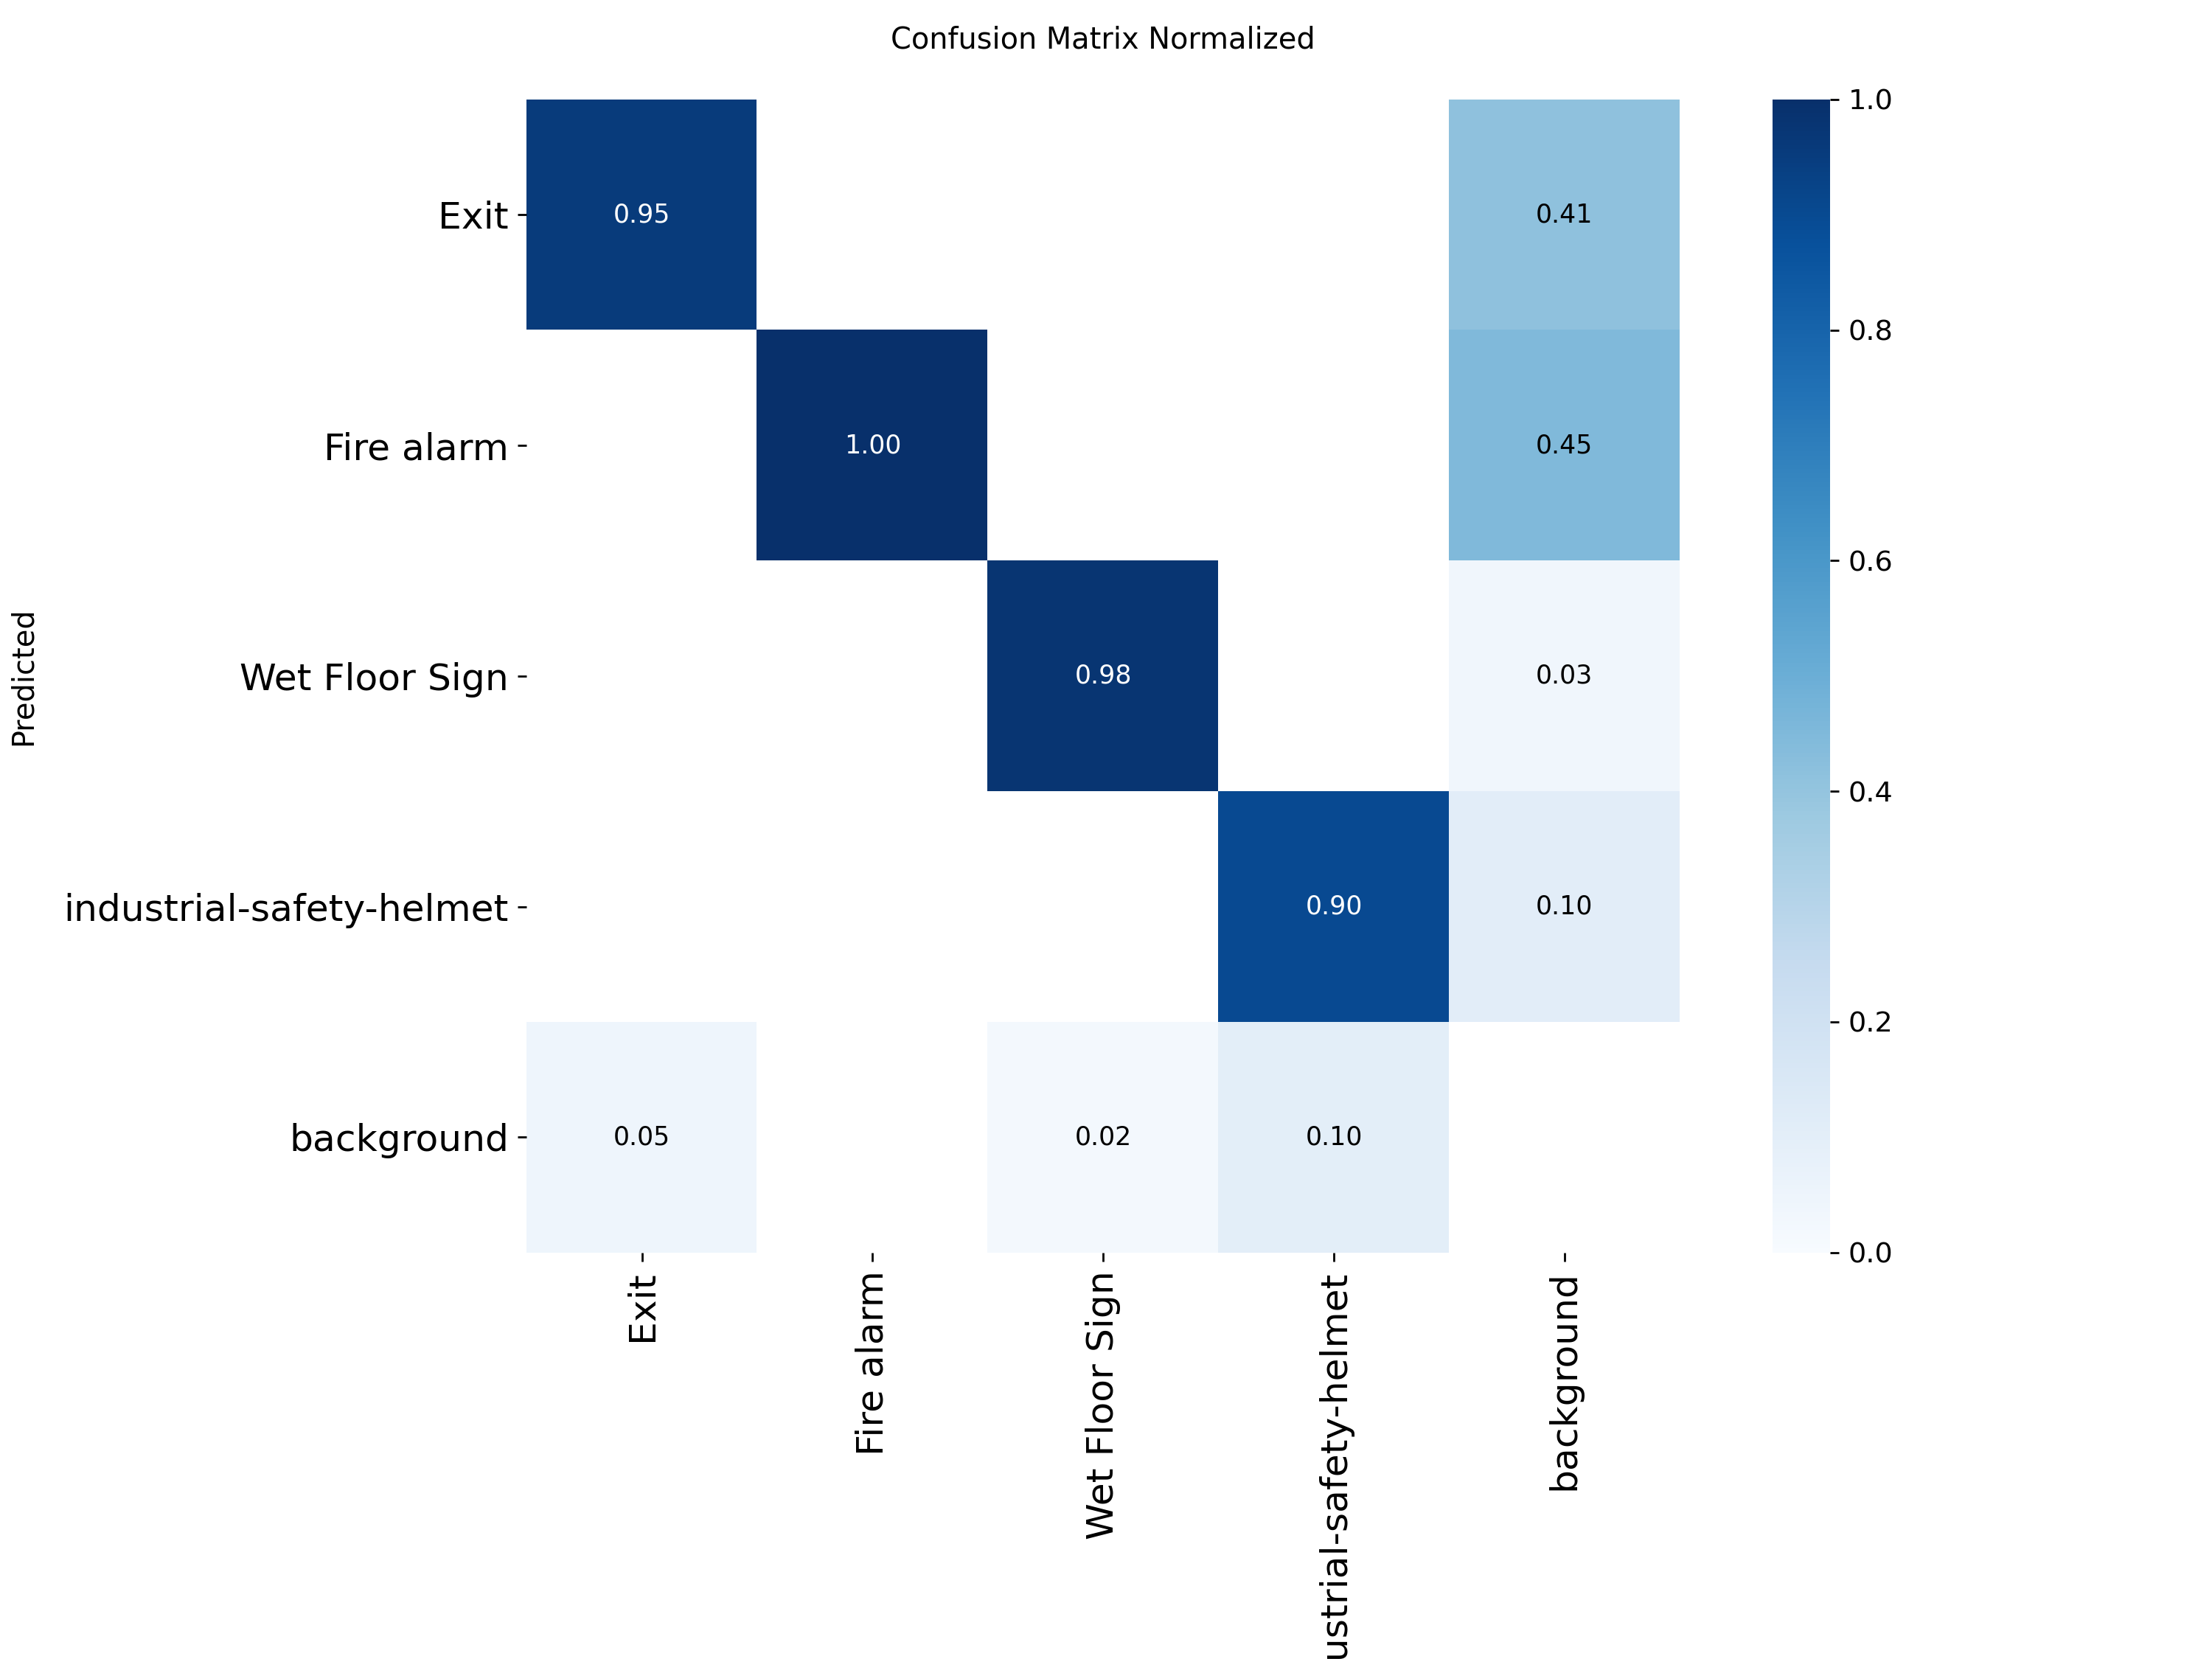

In [8]:
from IPython.display import Image, display
import glob

# Confusion matrix saved by val() with plots=True
cm_path = os.path.join(RUNS_DIR, 'baseline_test', 'confusion_matrix_normalized.png')
if os.path.exists(cm_path):
    print('Figure 1: Baseline Model — Normalised Confusion Matrix (Test Set)')
    display(Image(cm_path, width=600))
else:
    print(f'Confusion matrix not found at: {cm_path}')
    # Try alternate path
    alts = glob.glob(f'{RUNS_DIR}/**/confusion_matrix_normalized.png', recursive=True)
    if alts:
        print(f'Found at: {alts[0]}')
        display(Image(alts[0], width=600))

### Section 1c — Display Baseline PR Curve & F1 Curve

In [9]:
from IPython.display import Image, display

val_dir = os.path.join(RUNS_DIR, 'baseline_test')

curves = {
    'Figure 2: Baseline — Precision-Recall Curve': 'PR_curve.png',
    'Figure 3: Baseline — F1-Confidence Curve'   : 'F1_curve.png',
}

for title, fname in curves.items():
    path = os.path.join(val_dir, fname)
    if os.path.exists(path):
        print(title)
        display(Image(path, width=600))
    else:
        print(f'Not found: {path}')

Not found: /content/runs/detect/baseline_test/PR_curve.png
Not found: /content/runs/detect/baseline_test/F1_curve.png


### Section 1d — Baseline Weakness Analysis

Key weaknesses identified from the confusion matrix and per-class metrics:

1. **Exit class — lowest recall (~79.6%):** The model missed ~21% of actual exit signs. The confusion matrix shows a high false-negative rate against background, caused by high visual variation in exit sign designs across campus (different colours, arrow directions, illumination).
2. **mAP@0.50 vs mAP@0.50:0.95 gap (92.96% vs 66.91%):** Bounding boxes are not always tight — the model finds objects but sometimes draws loose boxes.
3. **Fire Alarm precision (70.24% on test):** Likely inflated by the very small test sample (13 images). Worth monitoring across experiments.

These weaknesses motivate the three improvement strategies below.

In [10]:
# Save baseline evaluation results to Drive
shutil.copytree(
    os.path.join(RUNS_DIR, 'baseline_test'),
    f'{DRIVE_BASE}/baseline',
    dirs_exist_ok=True
)
print('Baseline results saved to Drive ✓')

Baseline results saved to Drive ✓


---
## 🧪 Section 2 — Experiment 1: YOLOv8m Architecture Upgrade
**Category A — Strategy 1: Upgrade backbone from YOLOv8s → YOLOv8m**

**Justification:** The Exit class weakness (79.6% recall) stems partly from insufficient model capacity to learn the high intra-class visual variation in exit signs. YOLOv8m (25.9M parameters, 78.9 GFLOPs) provides 2.3× more parameters than YOLOv8s (11.2M, 28.7 GFLOPs), enabling richer feature extraction. All other settings are held constant to isolate the architecture effect.

**Hypothesis:** A larger model will improve Exit class recall and reduce the mAP@0.50:0.95 gap by producing tighter bounding boxes.

### Section 2a — Train YOLOv8m
> ⏱️ **Estimated time: ~75 minutes on Colab T4**

In [11]:
from ultralytics import YOLO

exp1_model = YOLO('yolov8m.pt')  # Downloads ~52MB automatically

exp1_results = exp1_model.train(
    data        = os.path.join(DATASET_PATH, 'data.yaml'),
    epochs      = 50,
    batch       = 16,
    imgsz       = 640,
    patience    = 15,
    seed        = SEED,
    device      = DEVICE,
    project     = RUNS_DIR,
    name        = 'exp1_yolov8m',
    exist_ok    = True,
    # Augmentations — same as Part 1 baseline for fair comparison
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 5.0,
    flipud      = 0.1,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.1,
)

print(f'\nExp 1 training complete.')
print(f'Best weights: {exp1_results.save_dir}/weights/best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BCS_407-Project-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [12]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Save Exp 1 weights to Drive
src = '/content/runs/detect/exp1_yolov8m/weights/best.pt'
dst = '/content/drive/MyDrive/BCS407_Part2/exp1_yolov8m/best.pt'
os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copy(src, dst)
print(f"Saved: {dst}")

# Also run test set eval and save results
from ultralytics import YOLO
exp1_model = YOLO(src)
test_results = exp1_model.val(
    data=os.path.join(DATASET_PATH, 'data.yaml'),
    split='test', conf=0.25, iou=0.5, verbose=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/BCS407_Part2/exp1_yolov8m/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 217.9±319.6 MB/s, size: 34.9 KB)
val: Scanning /content/BCS_407-Project-1/test/labels.cache... 207 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 72.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 38, len(boxes) = 210. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.9it/s 6.9s
                   

### Section 2b — Evaluate Experiment 1 on Test Set

In [13]:
exp1_metrics = exp1_model.val(
    data    = os.path.join(DATASET_PATH, 'data.yaml'),
    split   = 'test',
    iou     = EVAL_IOU,
    conf    = EVAL_CONF,
    device  = DEVICE,
    plots   = True,
    name    = 'exp1_yolov8m_test',
    project = RUNS_DIR,
)

print('\n' + '='*57)
print('EXPERIMENT 1 RESULTS — YOLOv8m (Test Set)')
print('='*57)
print(f'Overall mAP@0.50      : {exp1_metrics.box.map50:.4f}')
print(f'Overall mAP@0.50:0.95 : {exp1_metrics.box.map:.4f}')
print(f'Overall Precision     : {exp1_metrics.box.mp:.4f}')
print(f'Overall Recall        : {exp1_metrics.box.mr:.4f}')
print()
print(f'{"Class":<30} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10}')
print('-'*62)
for i, name in enumerate(class_names):
    p  = exp1_metrics.box.p[i]     if i < len(exp1_metrics.box.p)     else 0
    r  = exp1_metrics.box.r[i]     if i < len(exp1_metrics.box.r)     else 0
    ap = exp1_metrics.box.ap50[i]  if i < len(exp1_metrics.box.ap50)  else 0
    print(f'{name:<30} {p:>10.4f} {r:>10.4f} {ap:>10.4f}')
print('='*62)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1162.8±464.7 MB/s, size: 26.6 KB)
val: Scanning /content/BCS_407-Project-1/test/labels.cache... 207 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 86.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 38, len(boxes) = 210. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.8it/s 7.2s
                   all        207        210      0.898      0.925      0.924      0.665
                  Exit         40         44      0.951      0.875      0.938      0.625
            Fire alarm         13         19      0.738      0.947      0.893      0.575
        Wet Floor Sign    

### Section 2c — Display Experiment 1 Training Curves

In [16]:
# Check actual column names (mAP not found fix)
import pandas as pd
results_csv = os.path.join(RUNS_DIR, 'exp1_yolov8m', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


In [19]:
import pandas as pd
df = pd.read_csv('/content/runs/detect/exp1_yolov8m/results.csv')
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


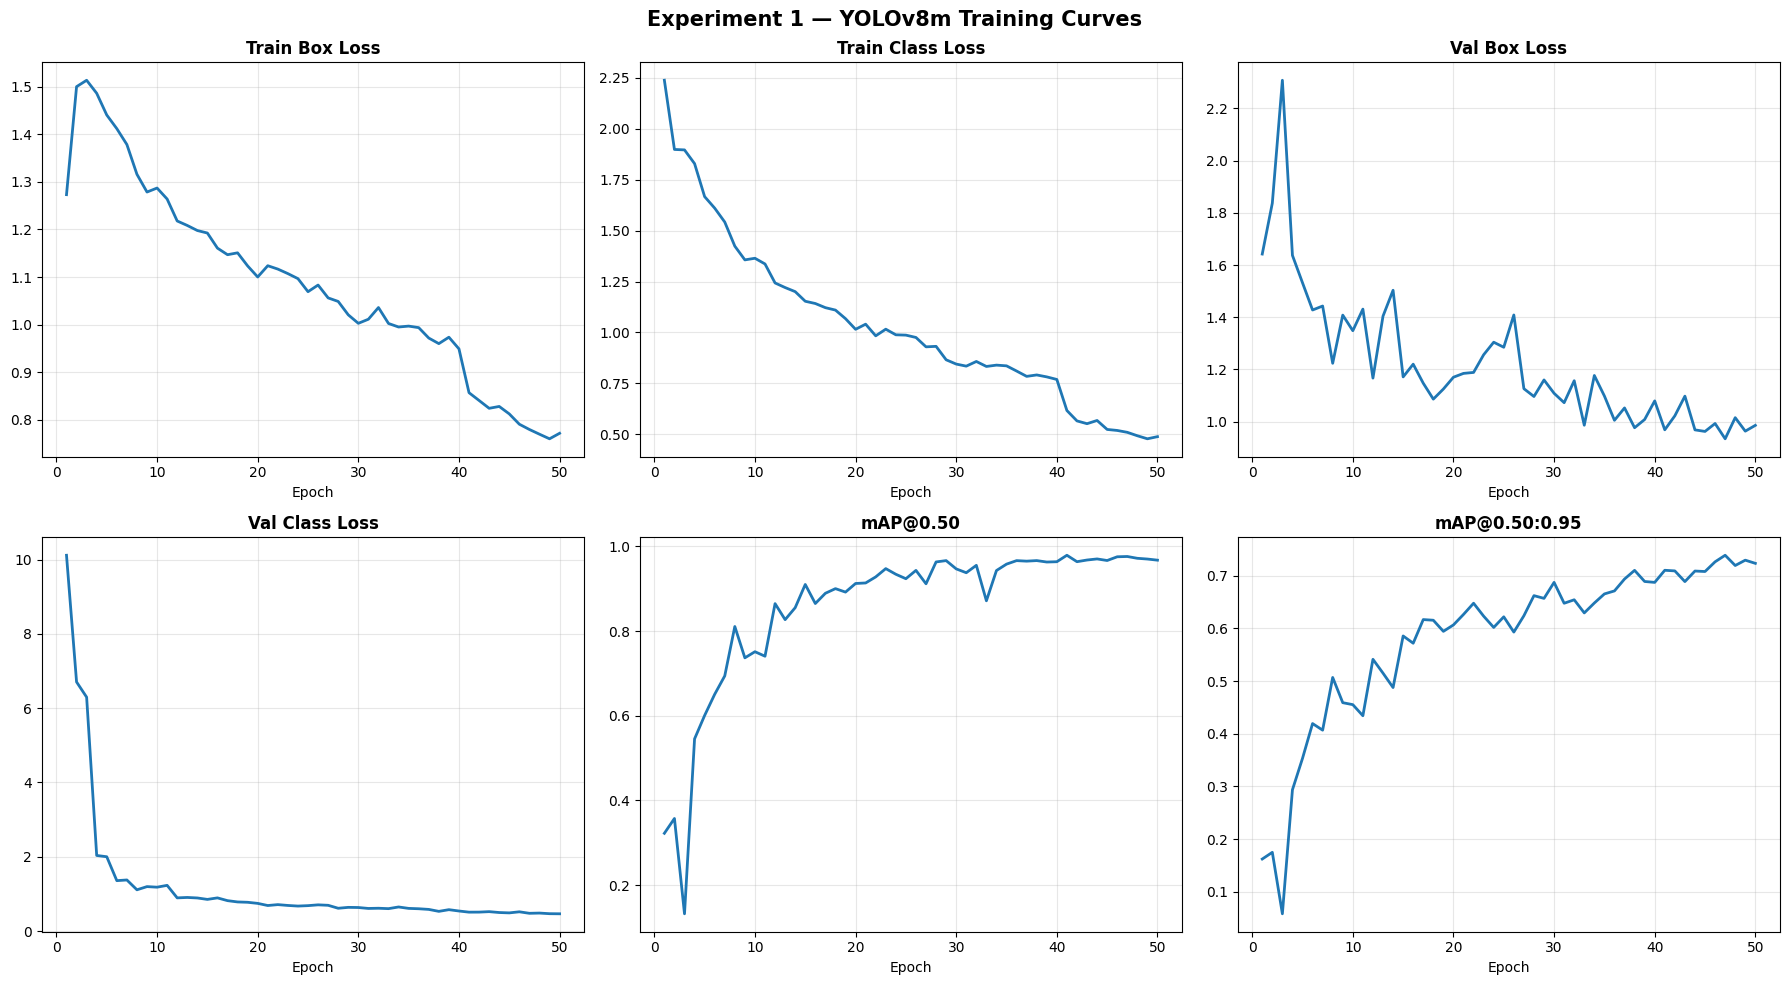

Figure 4: Experiment 1 — Training and Validation Loss Curves + mAP over 50 Epochs


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = os.path.join(RUNS_DIR, 'exp1_yolov8m', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment 1 — YOLOv8m Training Curves', fontsize=15, fontweight='bold')

plots = [
    ('train/box_loss',  'Train Box Loss',       axes[0, 0]),
    ('train/cls_loss',  'Train Class Loss',     axes[0, 1]),
    ('val/box_loss',    'Val Box Loss',         axes[0, 2]),
    ('val/cls_loss',    'Val Class Loss',       axes[1, 0]),
    ('metrics/mAP50(B)',    'mAP@0.50',      axes[1, 1]),
    ('metrics/mAP50-95(B)','mAP@0.50:0.95', axes[1, 2]),
]

for col, title, ax in plots:
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/exp1_yolov8m/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4: Experiment 1 — Training and Validation Loss Curves + mAP over 50 Epochs')

### Section 2d — Display Experiment 1 Confusion Matrix, PR Curve & F1 Curve

In [22]:
import os
train_dir = os.path.join(RUNS_DIR, 'exp1_yolov8m')
print([f for f in os.listdir(train_dir) if f.endswith('.png')])

['confusion_matrix.png', 'confusion_matrix_normalized.png', 'BoxP_curve.png', 'BoxPR_curve.png', 'BoxF1_curve.png', 'results.png', 'BoxR_curve.png']


Figure 5: Exp 1 — Normalised Confusion Matrix (Test Set)


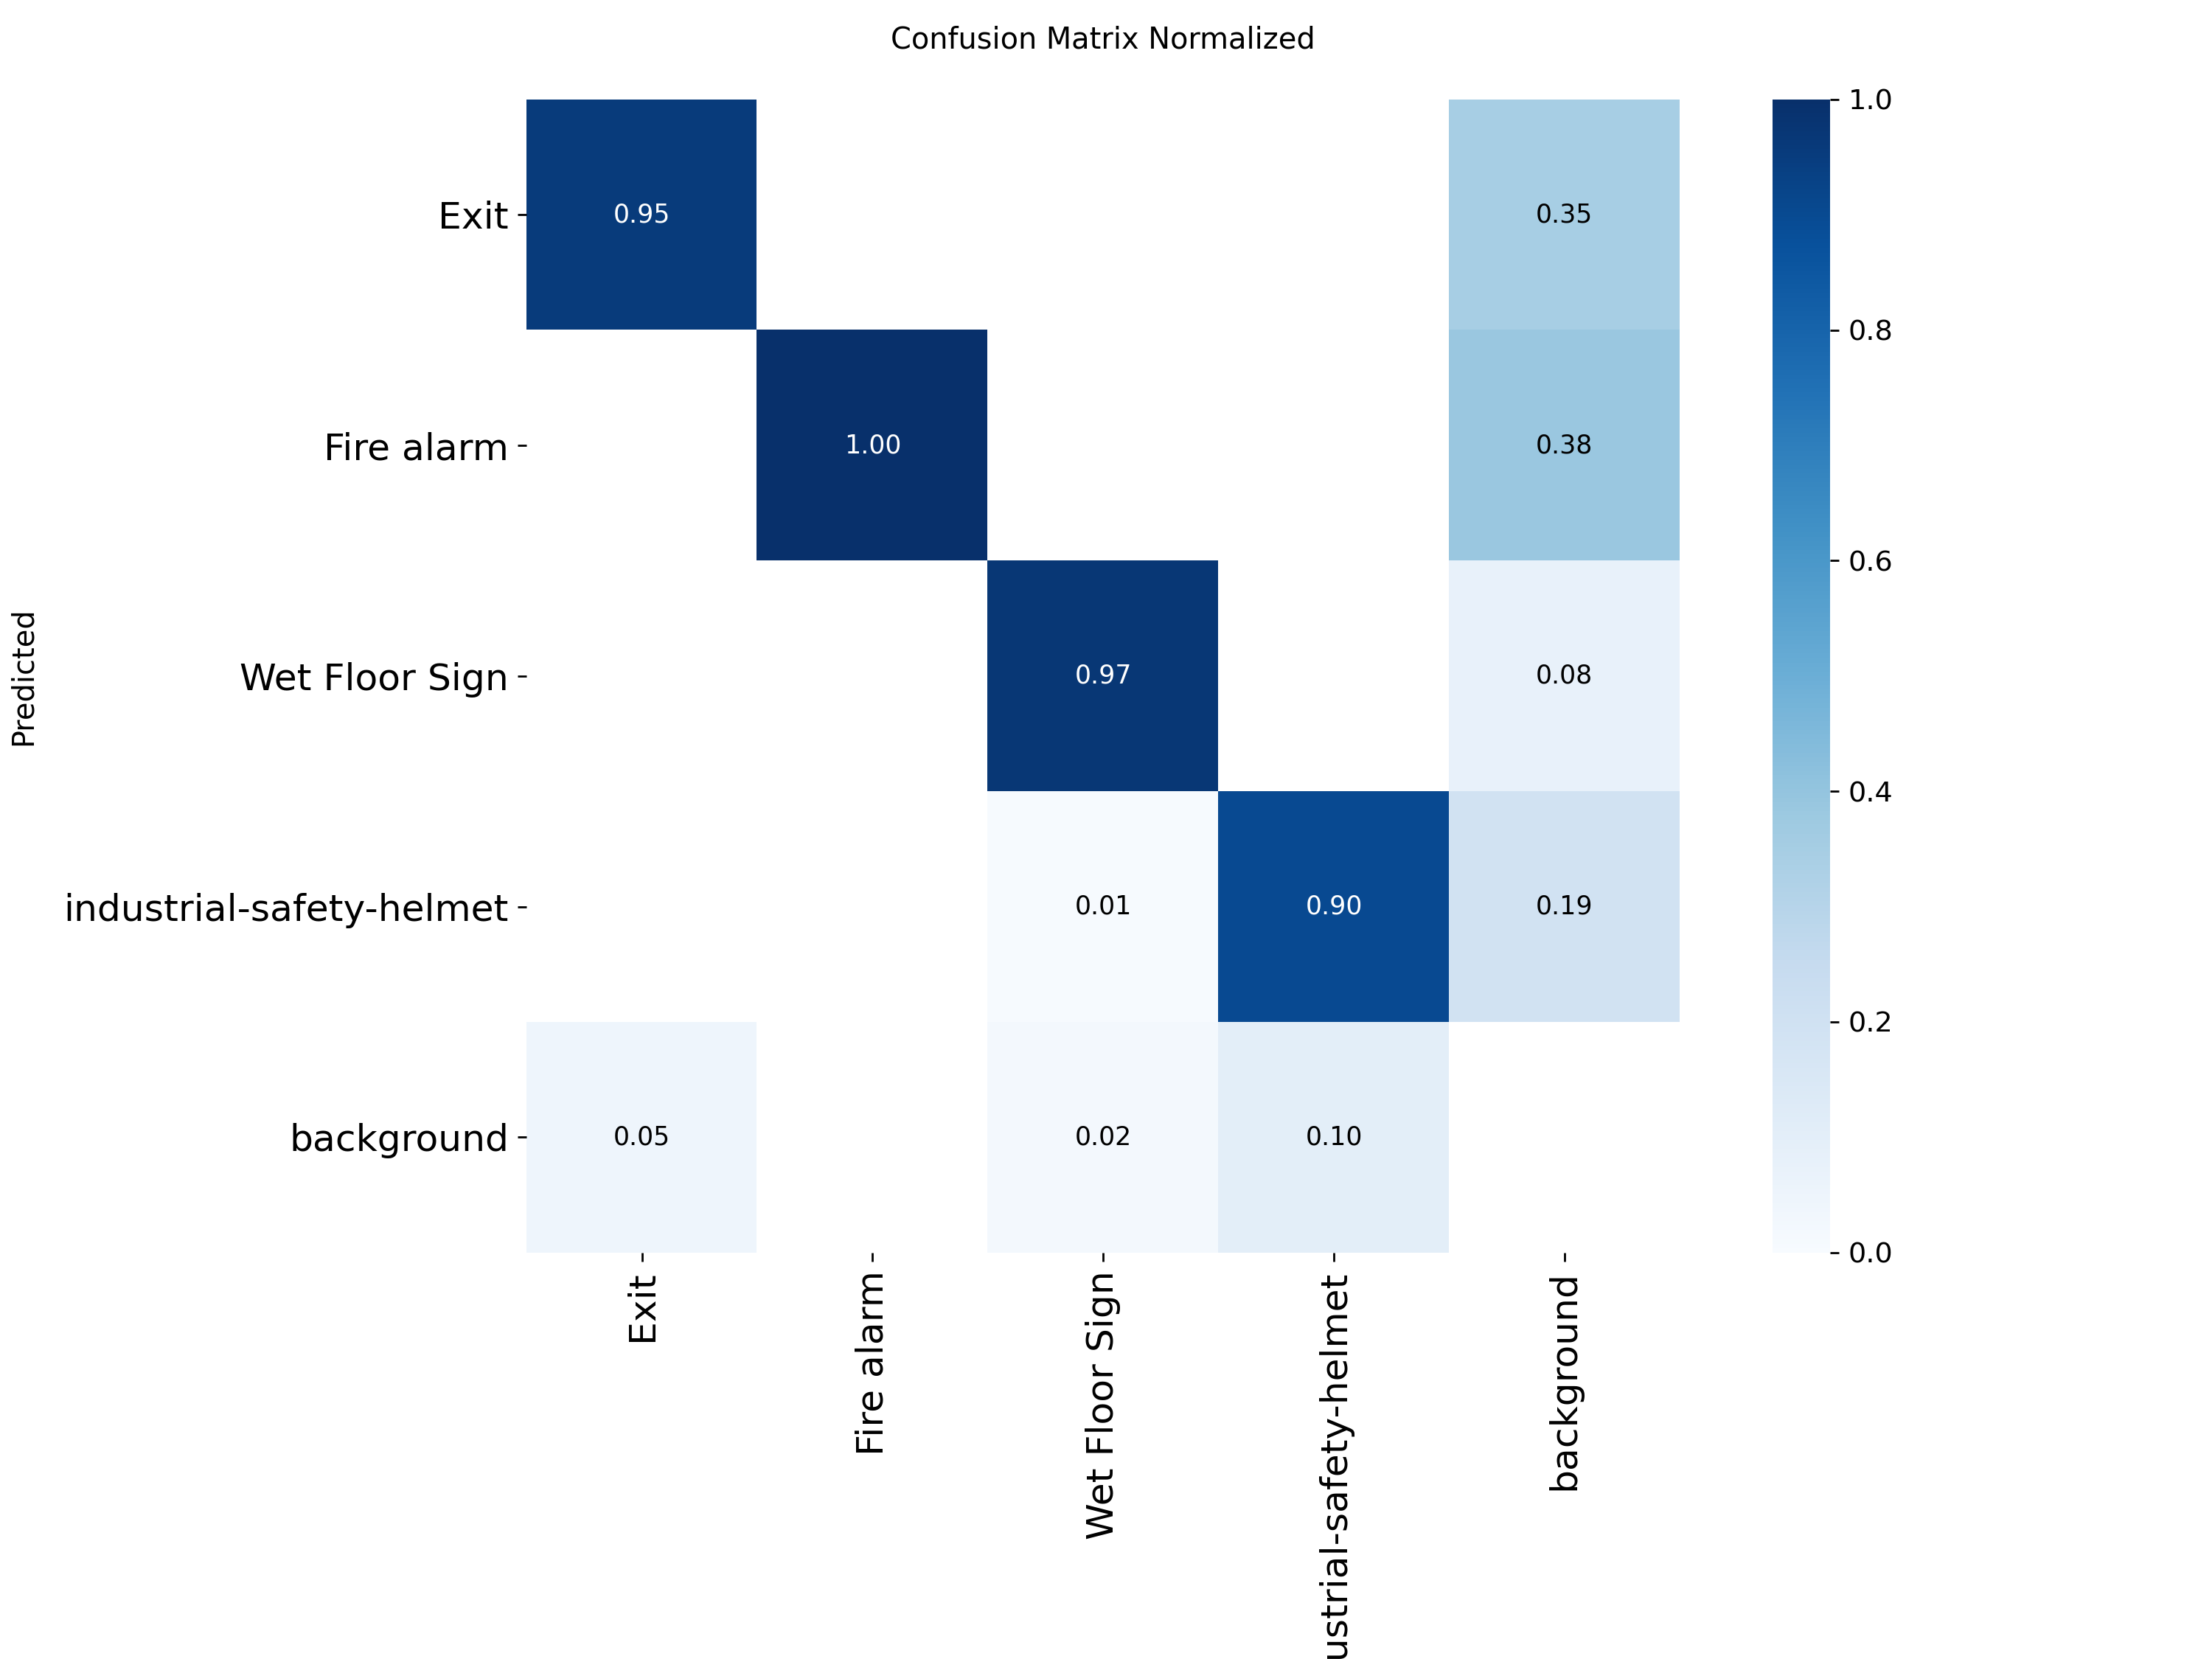

Figure 6: Exp 1 — Precision-Recall Curve


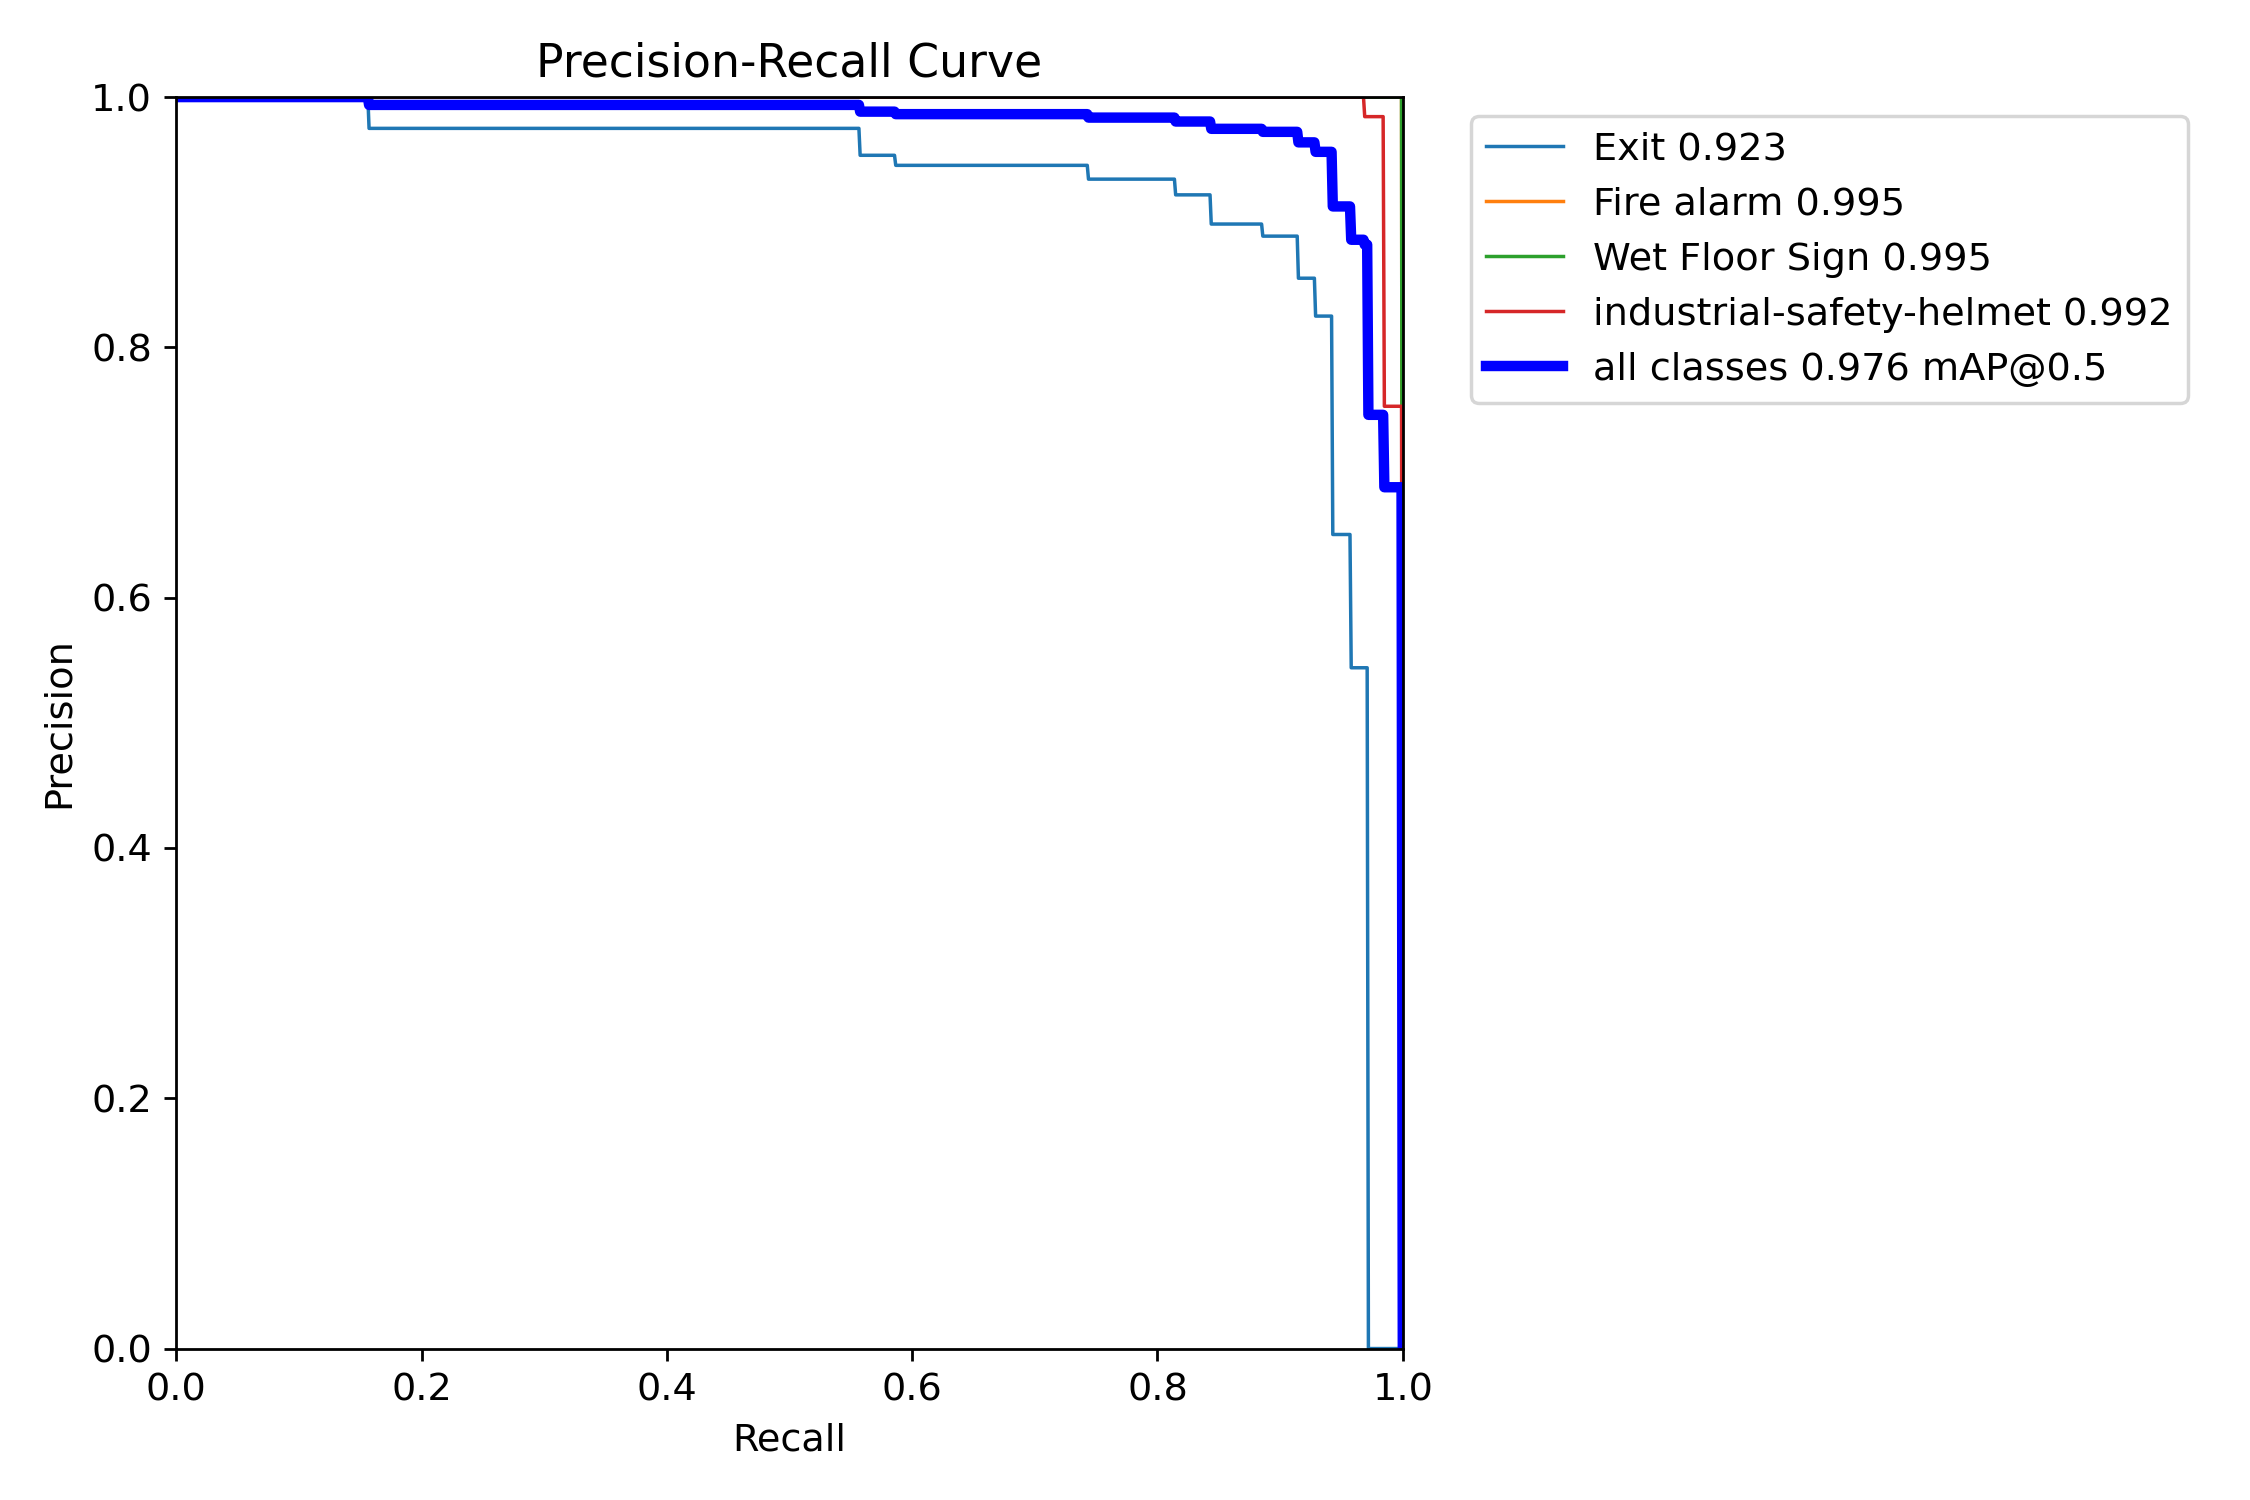

Figure 7: Exp 1 — F1-Confidence Curve


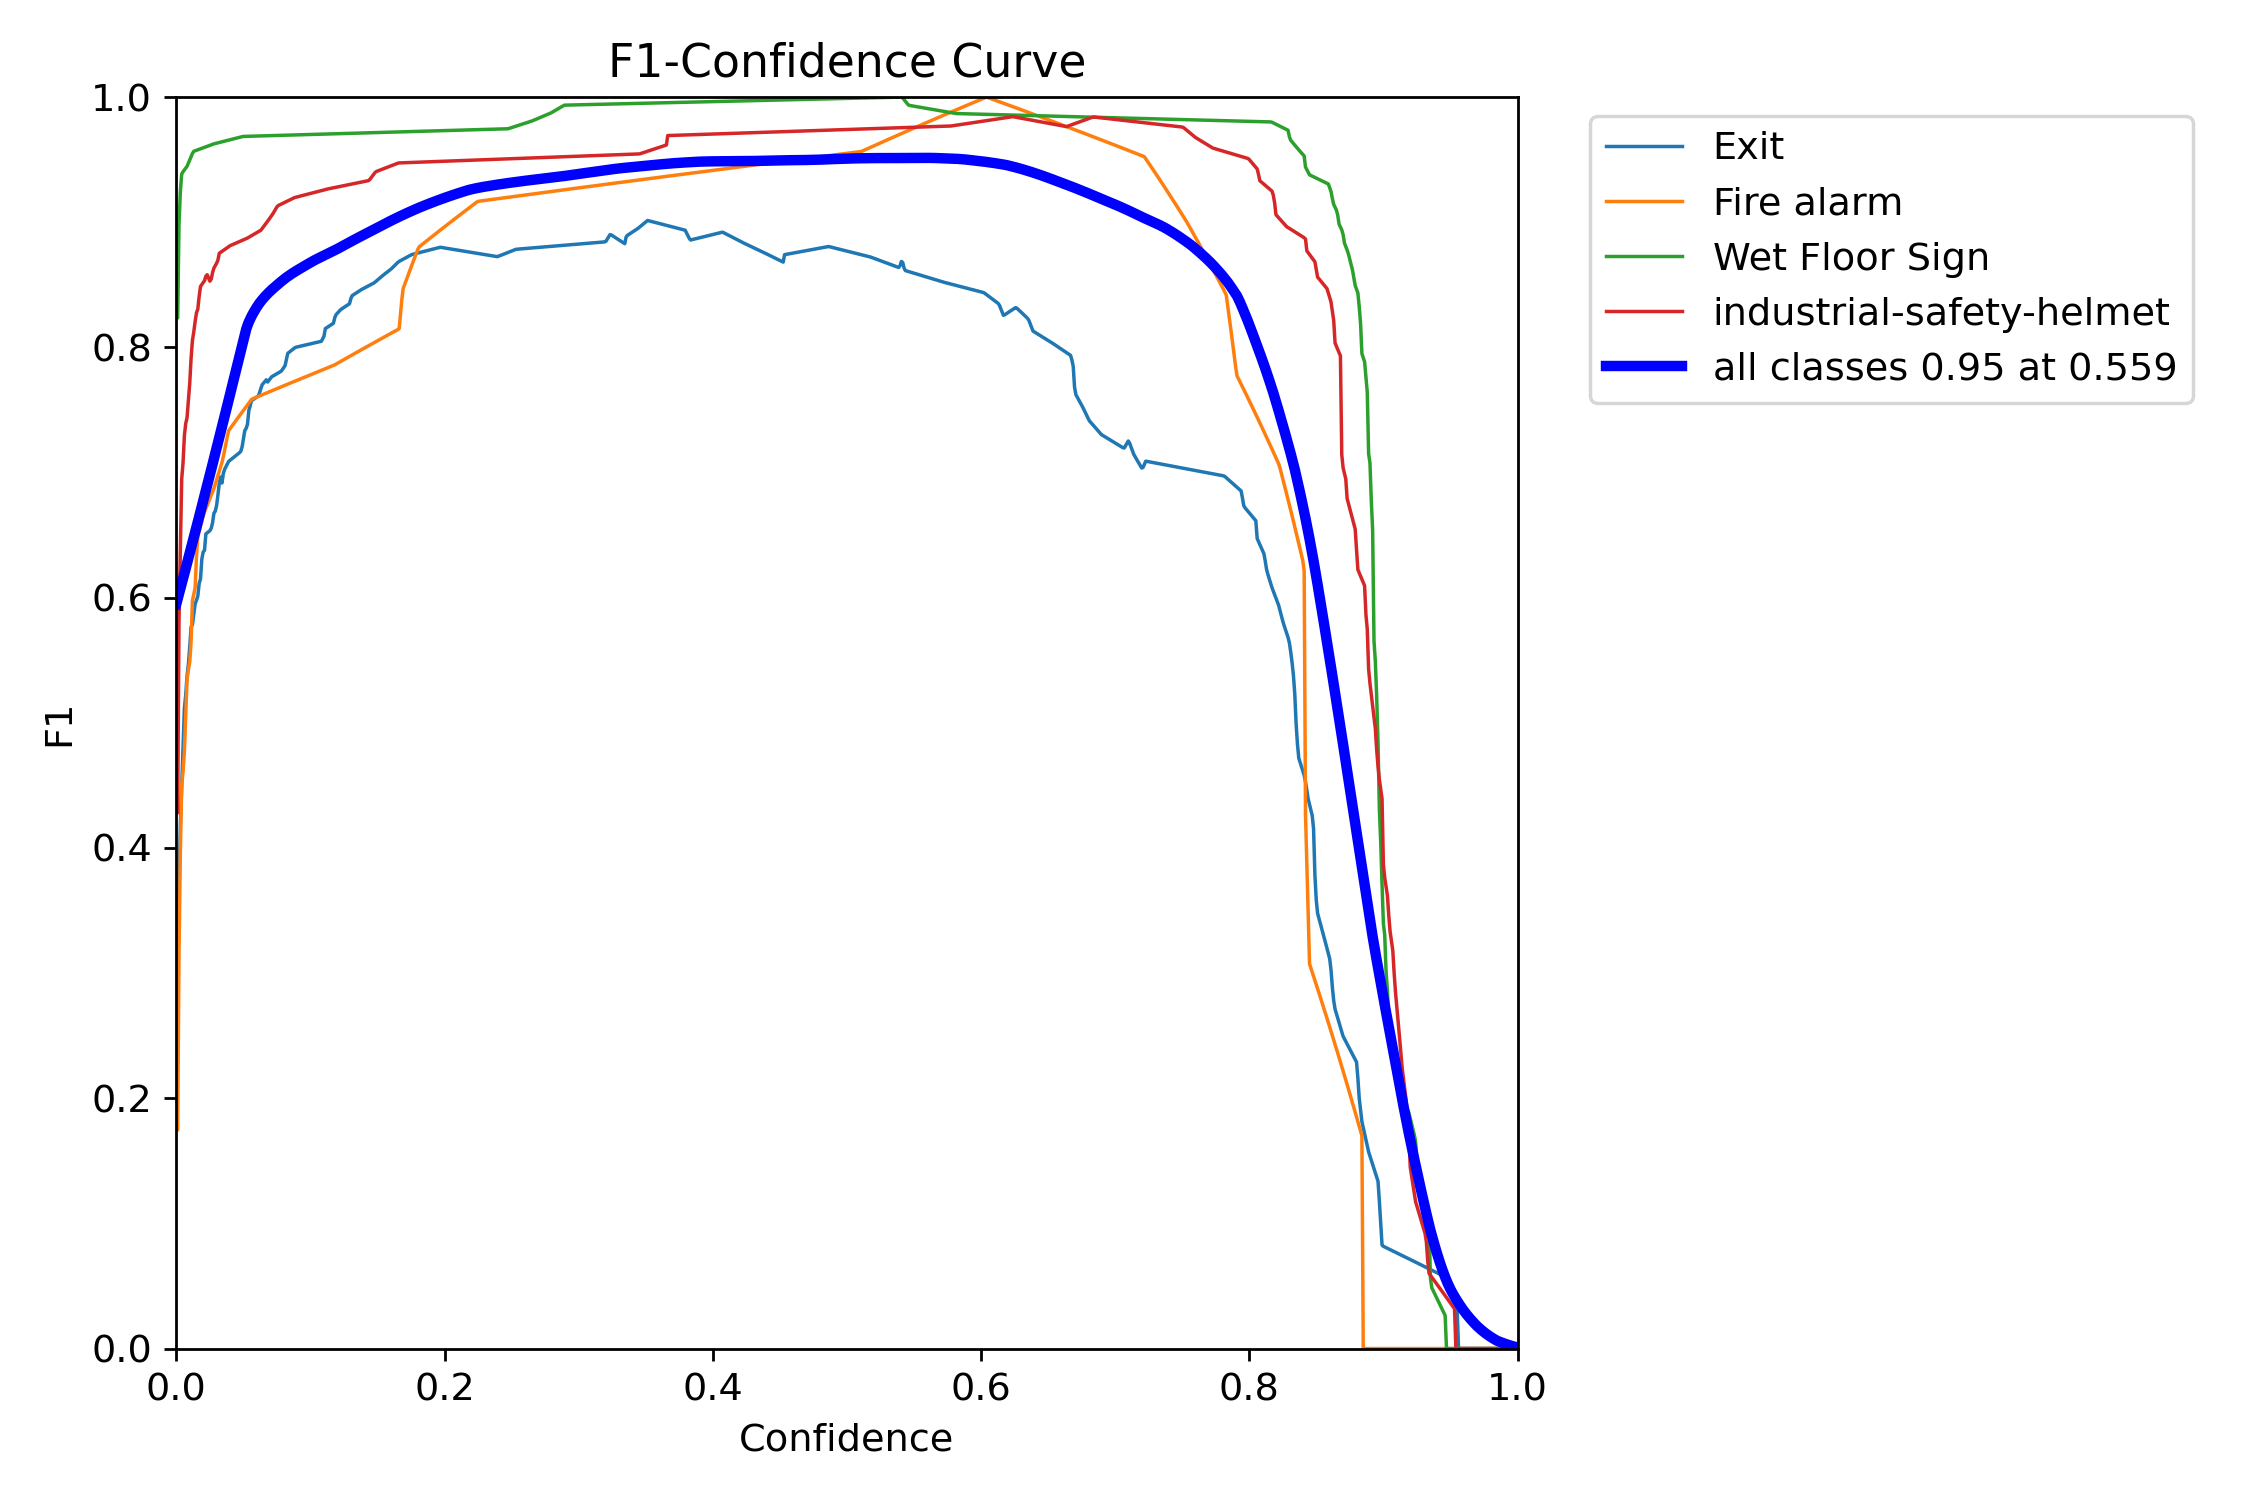

In [24]:
from IPython.display import Image, display

eval_dir = os.path.join(RUNS_DIR, 'exp1_yolov8m')  # training folder, not test

figures = {
    'Figure 5: Exp 1 — Normalised Confusion Matrix (Test Set)':
        os.path.join(RUNS_DIR, 'exp1_yolov8m_test', 'confusion_matrix_normalized.png'),
    'Figure 6: Exp 1 — Precision-Recall Curve':
        os.path.join(RUNS_DIR, 'exp1_yolov8m', 'BoxPR_curve.png'),
    'Figure 7: Exp 1 — F1-Confidence Curve':
        os.path.join(RUNS_DIR, 'exp1_yolov8m', 'BoxF1_curve.png'),
}

for title, path in figures.items():
    if os.path.exists(path):
        print(title)
        display(Image(path, width=600))
    else:
        print(f'Not found: {path}')

In [25]:
# Save Experiment 1 to Drive
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp1_yolov8m'),
    f'{DRIVE_BASE}/exp1_yolov8m/train',
    dirs_exist_ok=True
)
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp1_yolov8m_test'),
    f'{DRIVE_BASE}/exp1_yolov8m/test_eval',
    dirs_exist_ok=True
)
print('Experiment 1 saved to Drive ✓')

Experiment 1 saved to Drive ✓


---
## 🧪 Section 3 — Experiment 2: Hyperparameter Optimisation
**Category A — Strategy 3: Learning rate scheduling & regularisation**

**Justification:** The baseline model trained with the default AdamW settings (lr0=0.00125, lrf=0.01, weight_decay=0.0005). The gap between mAP@0.50 (92.96%) and mAP@0.50:0.95 (66.91%) suggests the model converges to imprecise bounding boxes. A lower initial learning rate encourages slower, more careful convergence; increased weight decay reduces overfitting; more epochs (75) allow the model to continue improving beyond the point where the baseline plateaued. All other settings (model size, dataset, augmentations) are held constant to isolate the hyperparameter effect.

**Hypothesis:** Tuned hyperparameters will reduce val losses further and narrow the mAP@0.50 vs mAP@0.50:0.95 gap.

### Section 3a — Train YOLOv8s with Tuned Hyperparameters
> ⏱️ **Estimated time: ~40 minutes on Colab T4**

In [26]:
from ultralytics import YOLO
import shutil, os

exp2_model = YOLO('yolov8s.pt')  # Same architecture as baseline

exp2_results = exp2_model.train(
    data          = os.path.join(DATASET_PATH, 'data.yaml'),
    epochs        = 75,           # More epochs (baseline: 50)
    batch         = 16,
    imgsz         = 640,
    patience      = 20,           # More patience (baseline: 15)
    seed          = SEED,
    device        = DEVICE,
    project       = RUNS_DIR,
    name          = 'exp2_hyperparam',
    exist_ok      = True,
    # Tuned hyperparameters
    optimizer     = 'AdamW',      # Explicit so lr0 is respected
    lr0           = 0.001,        # Lower initial LR (baseline: 0.00125)
    lrf           = 0.01,         # Final LR ratio (same)
    weight_decay  = 0.001,        # Higher regularisation (baseline: 0.0005)
    warmup_epochs = 5,            # Longer warmup (baseline: 3)
    # Augmentations — same as baseline
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    degrees       = 5.0,
    flipud        = 0.1,
    fliplr        = 0.5,
    mosaic        = 1.0,
    mixup         = 0.1,
)

print(f'\nExp 2 training complete.')
print(f'Best weights: {exp2_results.save_dir}/weights/best.pt')

# Save weights to Drive immediately
os.makedirs(f'{DRIVE_BASE}/exp2_hyperparam', exist_ok=True)
shutil.copy(
    f'{exp2_results.save_dir}/weights/best.pt',
    f'{DRIVE_BASE}/exp2_hyperparam/best.pt'
)
print('Exp 2 weights saved to Drive ✓')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BCS_407-Project-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_hyperparam, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

### Section 3b — Evaluate Experiment 2 on Test Set

In [27]:
exp2_metrics = exp2_model.val(
    data    = os.path.join(DATASET_PATH, 'data.yaml'),
    split   = 'test',
    iou     = EVAL_IOU,
    conf    = EVAL_CONF,
    device  = DEVICE,
    plots   = True,
    name    = 'exp2_hyperparam_test',
    project = RUNS_DIR,
)

print('\n' + '='*57)
print('EXPERIMENT 2 RESULTS — YOLOv8s Tuned HP (Test Set)')
print('='*57)
print(f'Overall mAP@0.50      : {exp2_metrics.box.map50:.4f}')
print(f'Overall mAP@0.50:0.95 : {exp2_metrics.box.map:.4f}')
print(f'Overall Precision     : {exp2_metrics.box.mp:.4f}')
print(f'Overall Recall        : {exp2_metrics.box.mr:.4f}')
print()
print(f'{"Class":<30} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10}')
print('-'*62)
for i, name in enumerate(class_names):
    p  = exp2_metrics.box.p[i]     if i < len(exp2_metrics.box.p)     else 0
    r  = exp2_metrics.box.r[i]     if i < len(exp2_metrics.box.r)     else 0
    ap = exp2_metrics.box.ap50[i]  if i < len(exp2_metrics.box.ap50)  else 0
    print(f'{name:<30} {p:>10.4f} {r:>10.4f} {ap:>10.4f}')
print('='*62)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1133.4±507.7 MB/s, size: 34.9 KB)
val: Scanning /content/BCS_407-Project-1/test/labels.cache... 207 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 54.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 38, len(boxes) = 210. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.9it/s 4.5s
                   all        207        210      0.938      0.917      0.945      0.698
                  Exit         40         44      0.925      0.864      0.952      0.662
            Fire alarm         13

### Section 3c — Display Experiment 2 Training Curves

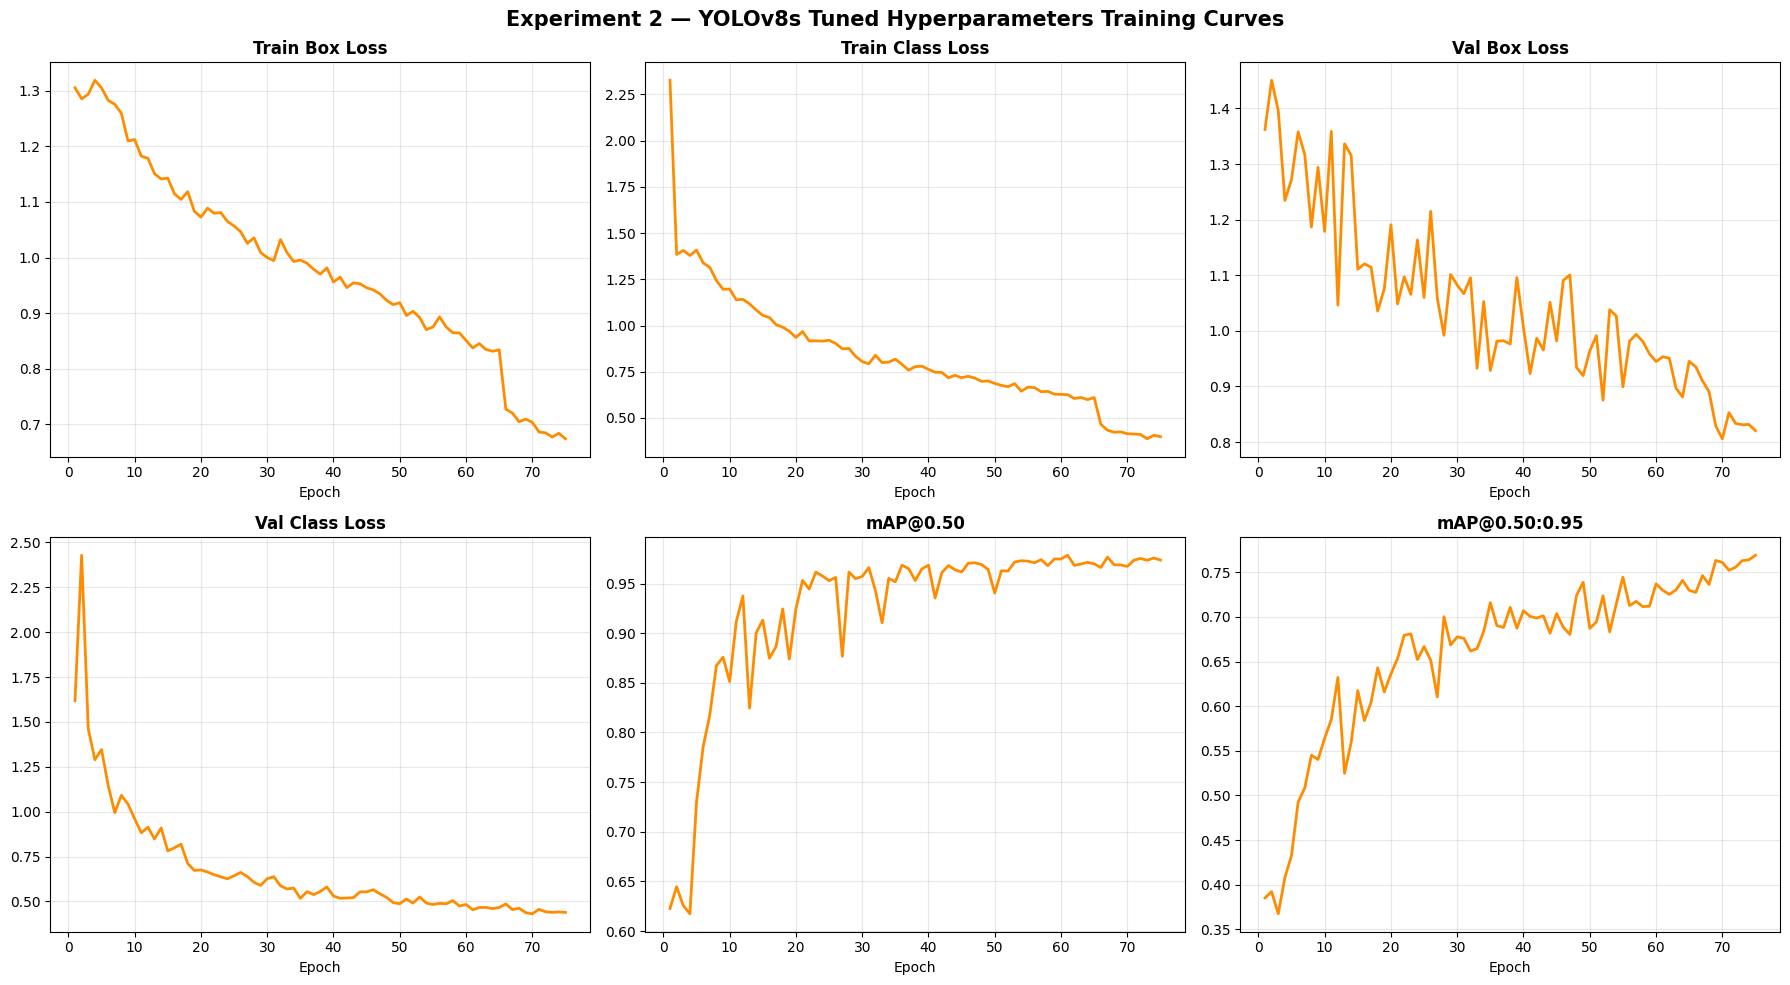

Figure 8: Experiment 2 — Training and Validation Loss Curves + mAP over 75 Epochs


In [28]:
results_csv = os.path.join(RUNS_DIR, 'exp2_hyperparam', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment 2 — YOLOv8s Tuned Hyperparameters Training Curves', fontsize=15, fontweight='bold')

for col, title, ax in [
    ('train/box_loss',   'Train Box Loss',    axes[0, 0]),
    ('train/cls_loss',   'Train Class Loss',  axes[0, 1]),
    ('val/box_loss',     'Val Box Loss',      axes[0, 2]),
    ('val/cls_loss',     'Val Class Loss',    axes[1, 0]),
    ('metrics/mAP50(B)',    'mAP@0.50',      axes[1, 1]),
    ('metrics/mAP50-95(B)','mAP@0.50:0.95', axes[1, 2]),
]:
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=2, color='darkorange')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/exp2_hyperparam/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8: Experiment 2 — Training and Validation Loss Curves + mAP over 75 Epochs')

### Section 3d — Display Experiment 2 Confusion Matrix, PR Curve & F1 Curve

Figure 9: Exp 2 — Normalised Confusion Matrix (Test Set)


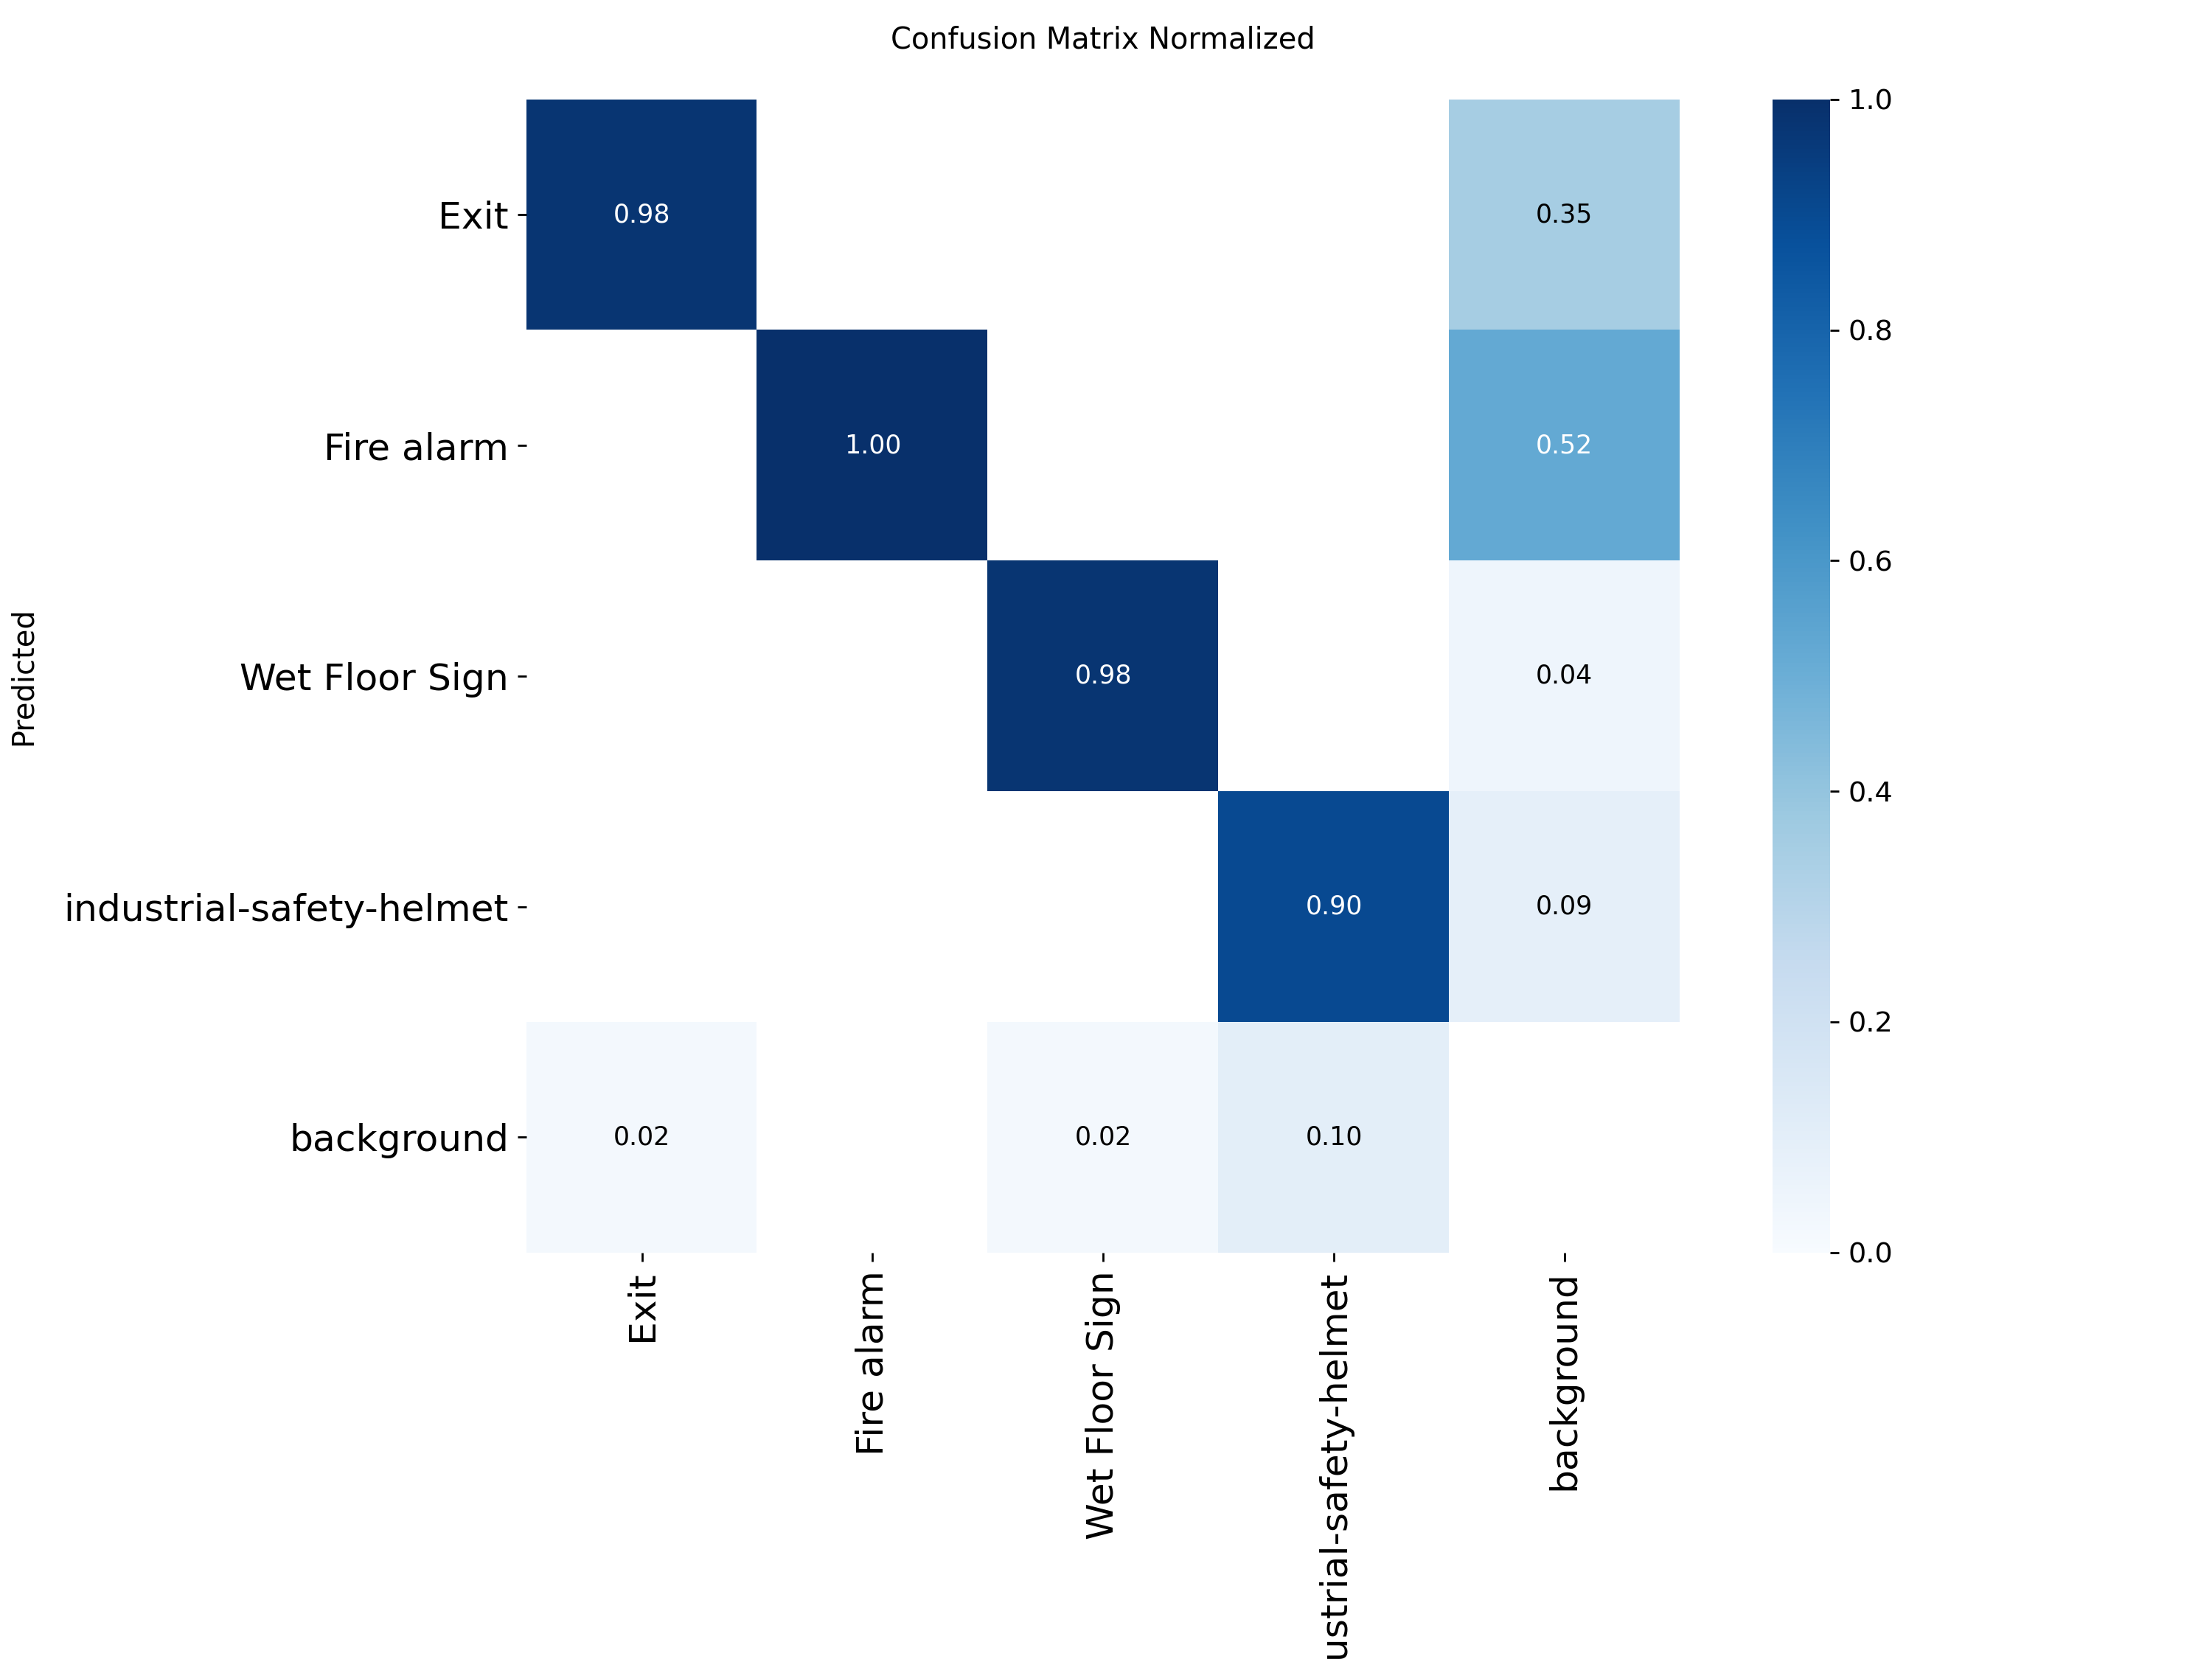

Figure 10: Exp 2 — Precision-Recall Curve


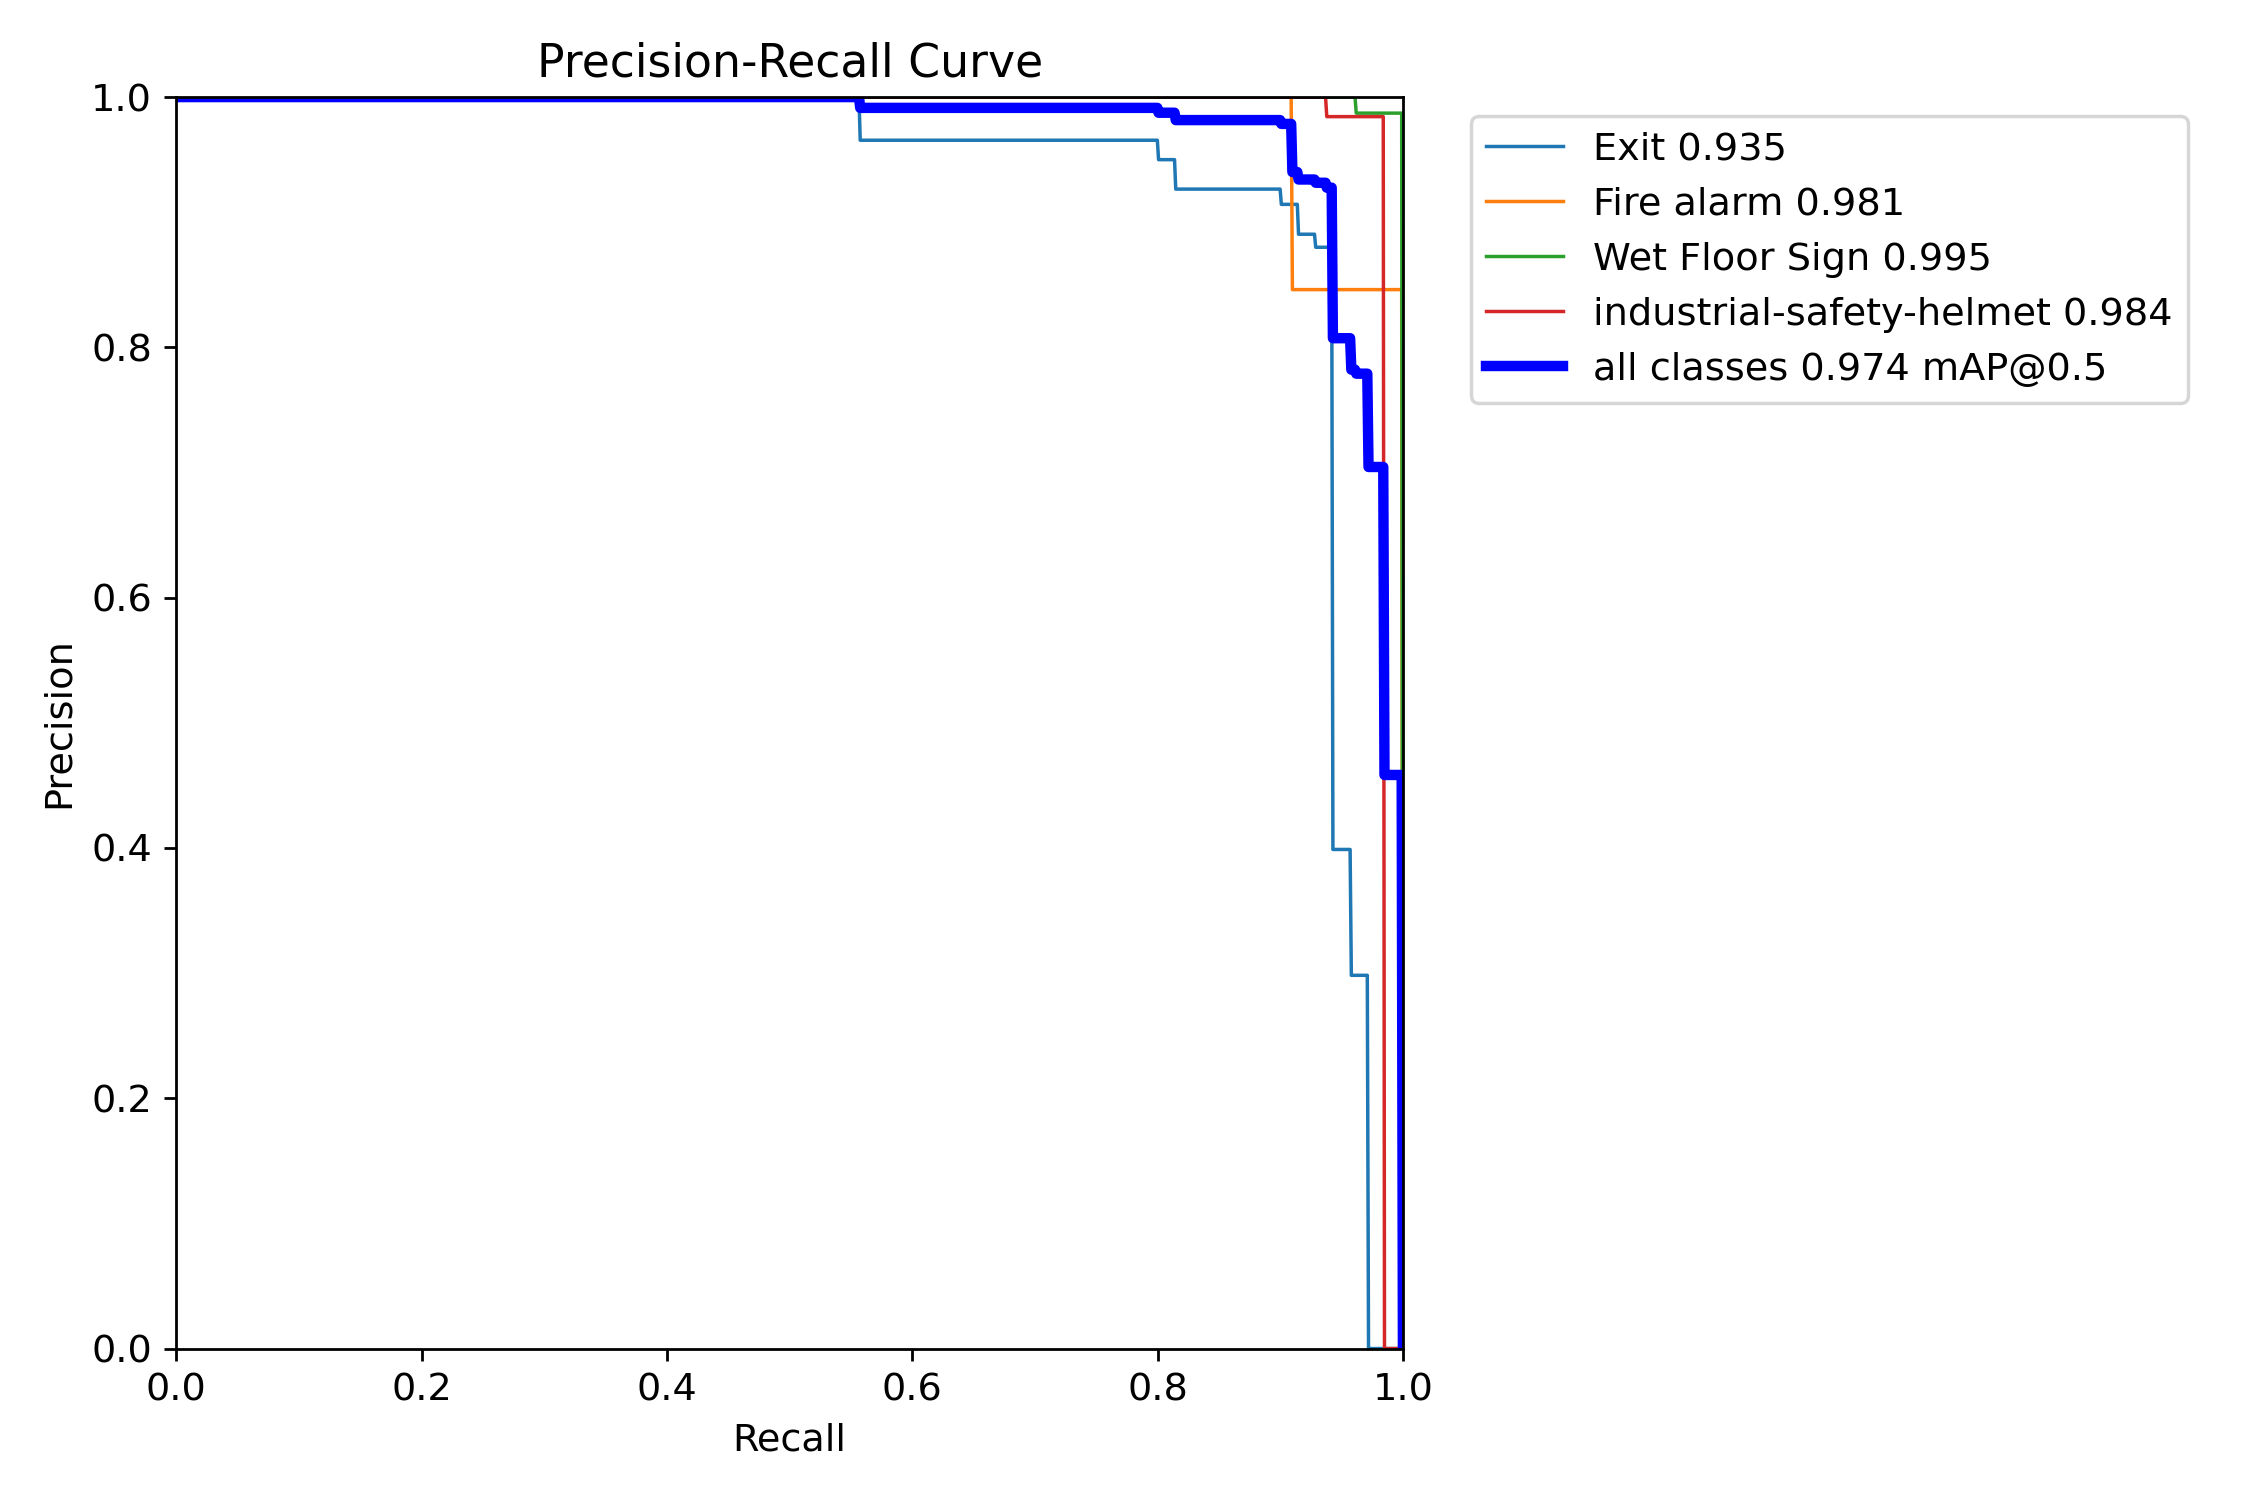

Figure 11: Exp 2 — F1-Confidence Curve


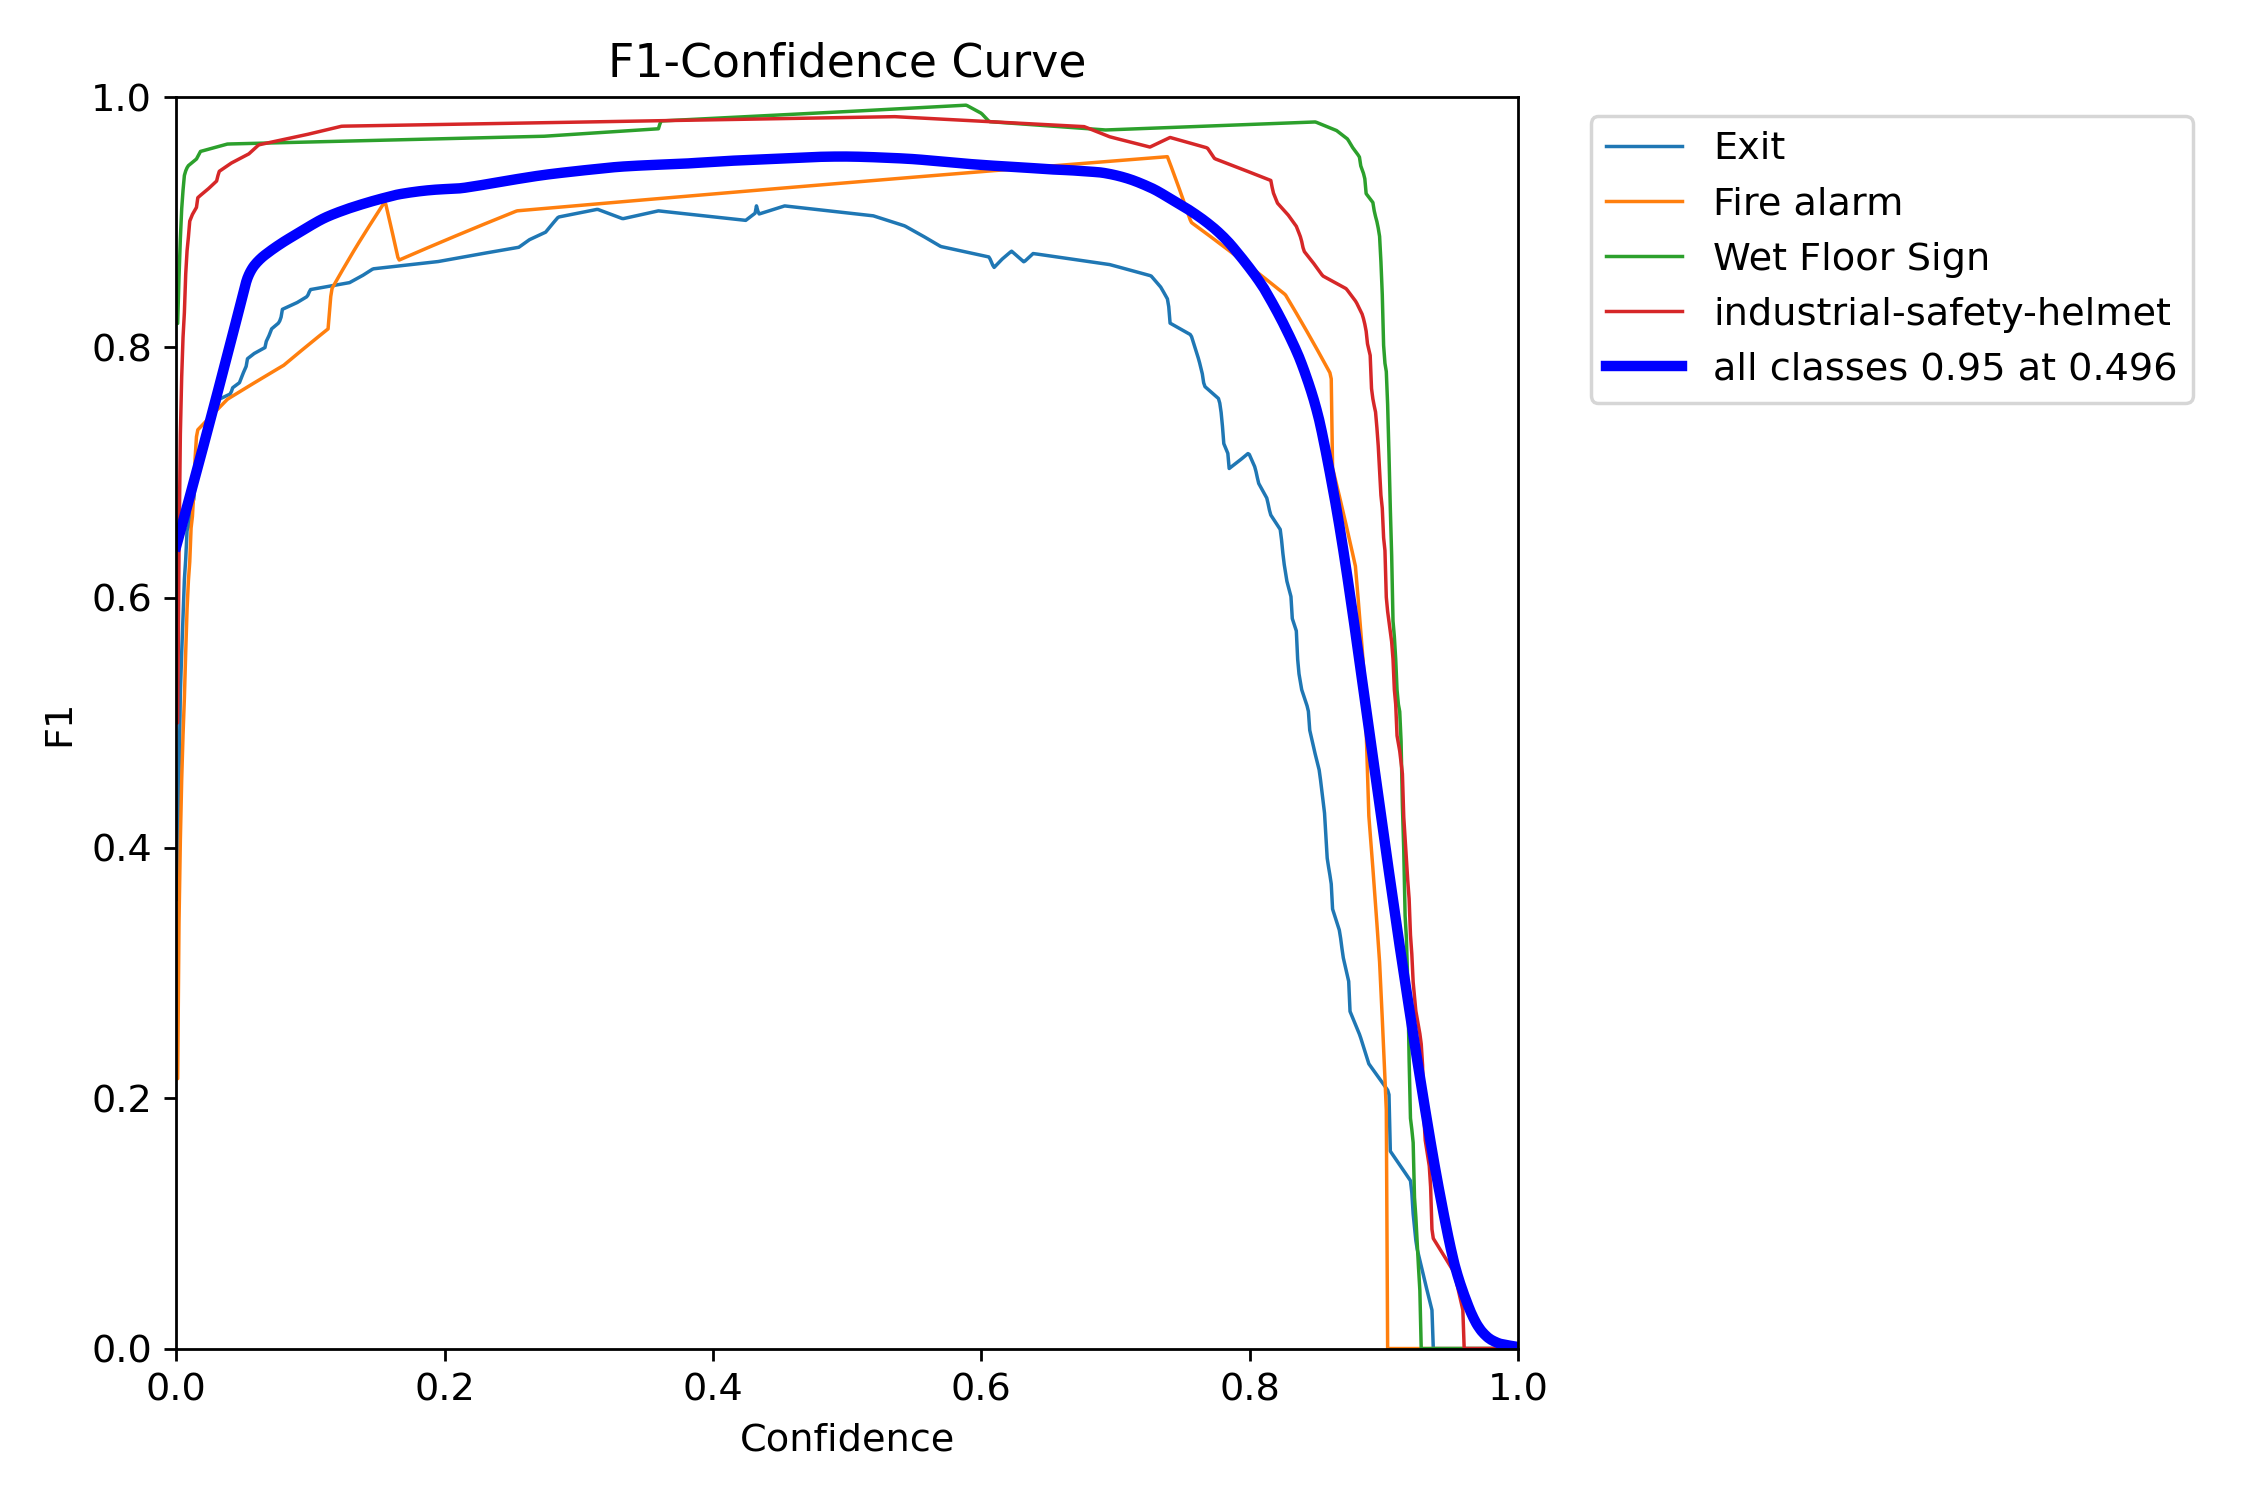

In [31]:
from IPython.display import Image, display

figures = {
    'Figure 9: Exp 2 — Normalised Confusion Matrix (Test Set)':
        os.path.join(RUNS_DIR, 'exp2_hyperparam_test', 'confusion_matrix_normalized.png'),
    'Figure 10: Exp 2 — Precision-Recall Curve':
        os.path.join(RUNS_DIR, 'exp2_hyperparam', 'BoxPR_curve.png'),
    'Figure 11: Exp 2 — F1-Confidence Curve':
        os.path.join(RUNS_DIR, 'exp2_hyperparam', 'BoxF1_curve.png'),
}

for title, path in figures.items():
    if os.path.exists(path):
        print(title)
        display(Image(path, width=600))
    else:
        print(f'Not found: {path}')

In [30]:
# Save Experiment 2 to Drive
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp2_hyperparam'),
    f'{DRIVE_BASE}/exp2_hyperparam/train',
    dirs_exist_ok=True
)
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp2_hyperparam_test'),
    f'{DRIVE_BASE}/exp2_hyperparam/test_eval',
    dirs_exist_ok=True
)
print('Experiment 2 saved to Drive ✓')

Experiment 2 saved to Drive ✓


---
## 🧪 Section 4 — Experiment 3: Expanded Exit Class Dataset
**Category B — Strategy 5: Expand dataset targeting underperforming class**

**Justification:** The confusion matrix showed 58% of actual Exit signs were missed (false negatives), producing the lowest recall of all classes (79.6%). The Exit class had only 494 annotations in the original dataset, covering limited variation. Li et al. (2020) showed that dataset diversity is a stronger driver of robustness than raw size. Collecting ~100–150 new Exit images targeting illuminated signs, varied arrow directions, and partial occlusion directly addresses the documented failure mode. Model architecture (YOLOv8s) and hyperparameters are held constant to isolate the data effect.

**Before running this section:**
1. Collect 100–150 new Exit sign images on campus
2. Upload and annotate them in Roboflow under the same project
3. Export as a new dataset version (VERSION = 2)
4. Update `EXPANDED_VERSION` below

### Section 4a — Download Expanded Dataset

In [ ]:
from roboflow import Roboflow

EXPANDED_VERSION = 2  # Update this once new images are added to Roboflow

rf_exp = Roboflow(api_key=API_KEY)
project_exp = rf_exp.workspace(WORKSPACE).project(PROJECT_NAME)
dataset_exp = project_exp.version(EXPANDED_VERSION).download('yolov8')

DATASET_PATH_EXP = dataset_exp.location
print(f'Expanded dataset downloaded to: {DATASET_PATH_EXP}')

### Section 4b — Train YOLOv8s on Expanded Dataset
> ⏱️ **Estimated time: ~35 minutes on Colab T4**

In [ ]:
from ultralytics import YOLO

exp3_model = YOLO('yolov8s.pt')  # Same architecture as baseline

exp3_results = exp3_model.train(
    data         = os.path.join(DATASET_PATH_EXP, 'data.yaml'),
    epochs       = 50,
    batch        = 16,
    imgsz        = 640,
    patience     = 15,
    seed         = SEED,
    device       = DEVICE,
    project      = RUNS_DIR,
    name         = 'exp3_expanded_data',
    exist_ok     = True,
    # Hyperparameters — same as baseline
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 5.0,
    flipud       = 0.1,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
)

print(f'\nExp 3 training complete.')
print(f'Best weights: {exp3_results.save_dir}/weights/best.pt')

### Section 4c — Evaluate Experiment 3 on Test Set

In [ ]:
exp3_metrics = exp3_model.val(
    data    = os.path.join(DATASET_PATH_EXP, 'data.yaml'),
    split   = 'test',
    iou     = EVAL_IOU,
    conf    = EVAL_CONF,
    device  = DEVICE,
    plots   = True,
    name    = 'exp3_expanded_data_test',
    project = RUNS_DIR,
)

print('\n' + '='*57)
print('EXPERIMENT 3 RESULTS — YOLOv8s + Expanded Exit Data (Test Set)')
print('='*57)
print(f'Overall mAP@0.50      : {exp3_metrics.box.map50:.4f}')
print(f'Overall mAP@0.50:0.95 : {exp3_metrics.box.map:.4f}')
print(f'Overall Precision     : {exp3_metrics.box.mp:.4f}')
print(f'Overall Recall        : {exp3_metrics.box.mr:.4f}')
print()
print(f'{"Class":<30} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10}')
print('-'*62)
for i, name in enumerate(class_names):
    p  = exp3_metrics.box.p[i]     if i < len(exp3_metrics.box.p)     else 0
    r  = exp3_metrics.box.r[i]     if i < len(exp3_metrics.box.r)     else 0
    ap = exp3_metrics.box.ap50[i]  if i < len(exp3_metrics.box.ap50)  else 0
    print(f'{name:<30} {p:>10.4f} {r:>10.4f} {ap:>10.4f}')
print('='*62)

### Section 4d — Display Experiment 3 Training Curves, Confusion Matrix, PR & F1

In [ ]:
results_csv = os.path.join(RUNS_DIR, 'exp3_expanded_data', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Experiment 3 — YOLOv8s + Expanded Exit Dataset Training Curves', fontsize=15, fontweight='bold')

for col, title, ax in [
    ('train/box_loss',   'Train Box Loss',    axes[0, 0]),
    ('train/cls_loss',   'Train Class Loss',  axes[0, 1]),
    ('val/box_loss',     'Val Box Loss',      axes[0, 2]),
    ('val/cls_loss',     'Val Class Loss',    axes[1, 0]),
    ('metrics/mAP50',    'mAP@0.50',         axes[1, 1]),
    ('metrics/mAP50-95', 'mAP@0.50:0.95',   axes[1, 2]),
]:
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=2, color='green')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/exp3_expanded_data/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12: Experiment 3 — Training and Validation Loss Curves + mAP over 50 Epochs')

# Display eval figures
eval_dir = os.path.join(RUNS_DIR, 'exp3_expanded_data_test')
for title, fname in {
    'Figure 13: Exp 3 — Normalised Confusion Matrix': 'confusion_matrix_normalized.png',
    'Figure 14: Exp 3 — Precision-Recall Curve'     : 'PR_curve.png',
    'Figure 15: Exp 3 — F1-Confidence Curve'        : 'F1_curve.png',
}.items():
    path = os.path.join(eval_dir, fname)
    if os.path.exists(path):
        print(title)
        display(Image(path, width=600))

In [ ]:
# Save Experiment 3 to Drive
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp3_expanded_data'),
    f'{DRIVE_BASE}/exp3_expanded_data/train',
    dirs_exist_ok=True
)
shutil.copytree(
    os.path.join(RUNS_DIR, 'exp3_expanded_data_test'),
    f'{DRIVE_BASE}/exp3_expanded_data/test_eval',
    dirs_exist_ok=True
)
print('Experiment 3 saved to Drive ✓')

---
## 🏆 Section 5 — Final Combined Model
**YOLOv8m + Tuned Hyperparameters + Expanded Exit Dataset**

This model integrates all successful improvements identified in Experiments 1–3. The combination is justified only if individual experiments showed positive results. Update the justification comment below after reviewing Experiment results.

> ⏱️ **Estimated time: ~90 minutes on Colab T4**

In [ ]:
from ultralytics import YOLO

# Final model: YOLOv8m + tuned HP + expanded Exit dataset
# Uses DATASET_PATH_EXP — update to DATASET_PATH if Exp 3 was not done
final_model = YOLO('yolov8m.pt')

final_results = final_model.train(
    data         = os.path.join(DATASET_PATH_EXP, 'data.yaml'),
    epochs       = 75,
    batch        = 16,
    imgsz        = 640,
    patience     = 20,
    seed         = SEED,
    device       = DEVICE,
    project      = RUNS_DIR,
    name         = 'final_combined',
    exist_ok     = True,
    # Tuned hyperparameters (from Exp 2)
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.001,
    warmup_epochs= 5,
    # Augmentations
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 5.0,
    flipud       = 0.1,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
)

print(f'\nFinal model training complete.')
print(f'Best weights: {final_results.save_dir}/weights/best.pt')

### Section 5b — Evaluate Final Model on Test Set

In [ ]:
final_metrics = final_model.val(
    data    = os.path.join(DATASET_PATH_EXP, 'data.yaml'),
    split   = 'test',
    iou     = EVAL_IOU,
    conf    = EVAL_CONF,
    device  = DEVICE,
    plots   = True,
    name    = 'final_combined_test',
    project = RUNS_DIR,
)

print('\n' + '='*57)
print('FINAL MODEL RESULTS — YOLOv8m + Tuned HP + Expanded Data')
print('='*57)
print(f'Overall mAP@0.50      : {final_metrics.box.map50:.4f}')
print(f'Overall mAP@0.50:0.95 : {final_metrics.box.map:.4f}')
print(f'Overall Precision     : {final_metrics.box.mp:.4f}')
print(f'Overall Recall        : {final_metrics.box.mr:.4f}')
print()
print(f'{"Class":<30} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10}')
print('-'*62)
for i, name in enumerate(class_names):
    p  = final_metrics.box.p[i]     if i < len(final_metrics.box.p)     else 0
    r  = final_metrics.box.r[i]     if i < len(final_metrics.box.r)     else 0
    ap = final_metrics.box.ap50[i]  if i < len(final_metrics.box.ap50)  else 0
    print(f'{name:<30} {p:>10.4f} {r:>10.4f} {ap:>10.4f}')
print('='*62)

### Section 5c — Final Model Training Curves, Confusion Matrix, PR & F1

In [ ]:
results_csv = os.path.join(RUNS_DIR, 'final_combined', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Final Combined Model — YOLOv8m + Tuned HP + Expanded Data', fontsize=15, fontweight='bold')

for col, title, ax in [
    ('train/box_loss',   'Train Box Loss',    axes[0, 0]),
    ('train/cls_loss',   'Train Class Loss',  axes[0, 1]),
    ('val/box_loss',     'Val Box Loss',      axes[0, 2]),
    ('val/cls_loss',     'Val Class Loss',    axes[1, 0]),
    ('metrics/mAP50',    'mAP@0.50',         axes[1, 1]),
    ('metrics/mAP50-95', 'mAP@0.50:0.95',   axes[1, 2]),
]:
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=2, color='purple')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/final_combined/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 16: Final Model — Training and Validation Loss Curves + mAP over 75 Epochs')

eval_dir = os.path.join(RUNS_DIR, 'final_combined_test')
for title, fname in {
    'Figure 17: Final — Normalised Confusion Matrix': 'confusion_matrix_normalized.png',
    'Figure 18: Final — Precision-Recall Curve'     : 'PR_curve.png',
    'Figure 19: Final — F1-Confidence Curve'        : 'F1_curve.png',
}.items():
    path = os.path.join(eval_dir, fname)
    if os.path.exists(path):
        print(title)
        display(Image(path, width=600))

In [ ]:
# Save final model to Drive
shutil.copytree(
    os.path.join(RUNS_DIR, 'final_combined'),
    f'{DRIVE_BASE}/final_combined/train',
    dirs_exist_ok=True
)
shutil.copytree(
    os.path.join(RUNS_DIR, 'final_combined_test'),
    f'{DRIVE_BASE}/final_combined/test_eval',
    dirs_exist_ok=True
)
# Also save final weights separately for easy access
shutil.copy(
    os.path.join(RUNS_DIR, 'final_combined', 'weights', 'best.pt'),
    '/content/drive/MyDrive/BCS407_Part2_final_best.pt'
)
print('Final model saved to Drive ✓')
print('Final weights: /content/drive/MyDrive/BCS407_Part2_final_best.pt')

---
## 📋 Section 6 — Consolidated Results Table
Baseline vs all experiments vs final model

In [ ]:
# ── Fill in results after running all experiments ──────────────────────────
# This cell compiles all metrics into a single comparison table.
# If an experiment was skipped, set its metrics object to None.

results_summary = [
    ('Baseline (YOLOv8s)',               baseline_metrics),
    ('Exp 1 — YOLOv8m',                  exp1_metrics),
    ('Exp 2 — YOLOv8s Tuned HP',         exp2_metrics),
    ('Exp 3 — YOLOv8s + Expanded Data',  exp3_metrics),
    ('Final — YOLOv8m + Tuned + Expanded', final_metrics),
]

print('='*85)
print('CONSOLIDATED RESULTS — All Experiments (Test Set)')
print('='*85)
print(f'{"Model":<40} {"Precision":>10} {"Recall":>10} {"mAP@0.50":>10} {"mAP@0.5:0.95":>13}')
print('-'*85)
for label, m in results_summary:
    if m is not None:
        print(f'{label:<40} {m.box.mp:>10.4f} {m.box.mr:>10.4f} {m.box.map50:>10.4f} {m.box.map:>13.4f}')
    else:
        print(f'{label:<40} {"(not run)":>10}')
print('='*85)

---
## 🔍 Section 7 — Error Analysis
Sample predictions from the final model on test images, with focus on Exit class failures.

In [ ]:
import glob, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Run predictions on test set using final model
test_images_path = os.path.join(DATASET_PATH_EXP, 'test', 'images')

predictions = final_model.predict(
    source   = test_images_path,
    iou      = EVAL_IOU,
    conf     = EVAL_CONF,
    device   = DEVICE,
    save     = True,
    project  = RUNS_DIR,
    name     = 'final_predictions',
    exist_ok = True,
)

print(f'Predictions saved to: {RUNS_DIR}/final_predictions')

In [ ]:
# Display 6 sample predictions
pred_dir = os.path.join(RUNS_DIR, 'final_predictions')
pred_images = sorted(glob.glob(os.path.join(pred_dir, '*.jpg')) +
                     glob.glob(os.path.join(pred_dir, '*.png')))

sample = random.sample(pred_images, min(6, len(pred_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 20: Final Model — Sample Predictions on Test Set', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/final_combined/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📄 Section 8 — Experiment Log
Summary table of all training runs for the report appendix

In [ ]:
print('='*100)
print('EXPERIMENT LOG — BCS407 Part 2')
print('='*100)
print(f'{"Run":<12} {"Model":<12} {"Dataset":<20} {"Epochs":>7} {"Batch":>6} {"LR0":>7} {"WD":>7} {"mAP@0.5":>9} {"mAP:0.95":>9}')
print('-'*100)

log = [
    ('Baseline', 'YOLOv8s', 'Original (2069)',  50, 16, 0.00125, 0.0005, baseline_metrics.box.map50, baseline_metrics.box.map),
    ('Exp 1',    'YOLOv8m', 'Original (2069)',  50, 16, 0.00125, 0.0005, exp1_metrics.box.map50,     exp1_metrics.box.map),
    ('Exp 2',    'YOLOv8s', 'Original (2069)',  75, 16, 0.001,   0.001,  exp2_metrics.box.map50,     exp2_metrics.box.map),
    ('Exp 3',    'YOLOv8s', 'Expanded Exit',    50, 16, 0.00125, 0.0005, exp3_metrics.box.map50,     exp3_metrics.box.map),
    ('Final',    'YOLOv8m', 'Expanded Exit',    75, 16, 0.001,   0.001,  final_metrics.box.map50,    final_metrics.box.map),
]

for run, model, data, epochs, batch, lr, wd, map50, map95 in log:
    print(f'{run:<12} {model:<12} {data:<20} {epochs:>7} {batch:>6} {lr:>7.5f} {wd:>7.4f} {map50:>9.4f} {map95:>9.4f}')

print('='*100)
print(f'Seed: {SEED} | Device: CUDA | eval iou={EVAL_IOU} conf={EVAL_CONF} | All runs evaluated on test split')

---
## 💾 Section 9 — Final Save & Cleanup

In [ ]:
print('='*55)
print('BCS407 PART 2 — COMPLETE')
print('='*55)
print(f'All results saved to   : {DRIVE_BASE}')
print(f'Final model weights    : /content/drive/MyDrive/BCS407_Part2_final_best.pt')
print()
print('Drive folder structure:')
print('  BCS407_Part2/')
print('  ├── baseline/               (test eval results)')
print('  ├── exp1_yolov8m/')
print('  │   ├── train/              (weights, curves)')
print('  │   └── test_eval/          (metrics, plots)')
print('  ├── exp2_hyperparam/')
print('  │   ├── train/')
print('  │   └── test_eval/')
print('  ├── exp3_expanded_data/')
print('  │   ├── train/')
print('  │   └── test_eval/')
print('  └── final_combined/')
print('      ├── train/')
print('      ├── test_eval/')
print('      └── sample_predictions.png')
print()
print('GitHub: commit this notebook to Abdulla1x/BCS407_Project')